# Experiment: Cross-Method Tiny-p Study

Objective:
- Compare `iid`, `mcmc_is`, and `samc` on fixed exact scenarios.
- Track estimates and diagnostics at intermediate estimation points, not just at the final budget.

In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "perm_pval").exists() and (candidate / "results").exists():
            return candidate
    raise RuntimeError("Could not locate project root containing perm_pval/ and results/.")


project_root = find_project_root()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from perm_pval.experiments.notebook_studies import (
    BetaSweepStudyConfig,
    CrossMethodStudyConfig,
    MCMCWorkflowConfig,
    SAMCWorkflowConfig,
    build_beta_workflow,
    create_timestamped_run_dir,
    load_beta_sweep_saved_output,
    load_cross_method_saved_output,
    load_selected_scenarios,
    regenerate_beta_sweep_plots_from_saved,
    regenerate_cross_method_plots_from_saved,
    run_beta_checkpoint_study,
    run_cross_method_study,
    save_beta_sweep_outputs,
    save_cross_method_outputs,
)

pd.set_option("display.max_columns", 100)
project_root

PosixPath('/Users/noamchowers/Documents/University/Thesis/Code/MCMCIS')

## Configuration

`ESTIMATION_POINTS` controls the intermediate checkpoints.  
The largest checkpoint is used for the main boxplots; all checkpoints are used for convergence diagnostics.  
In the cross-method notebook these are total budgets. For MCMC-IS, a fixed beta-selection budget is deducted first, and the production chain uses the remaining budget.

In [2]:
FAST_MODE = False
SAVE_OUTPUTS = True

CATALOG_PATH = project_root / "results" / "exact_scenarios" / "v1" / "catalog.json"
OUTPUT_ROOT = project_root / "results" / "cross_method_notebook"

SCENARIO_KEYS_TO_RUN = [
    "hypergeom_1e7",
    "gwas_additive_score_n40",
    "linear_stat_dp_n40",
    "bruteforce_welch_nonextreme_n22",
]

ESTIMATION_POINTS = (333_000, 1_000_000, 2_500_000, 5_000_000, 10_000_000) if not FAST_MODE else (50_000, 100_000, 200_000)
N_REPEATS = 7 if not FAST_MODE else 2
N_JOBS = min(N_REPEATS, os.cpu_count() or 1)
MIN_TAIL_STATES = 2
BASE_SEED = 12_345

cross_cfg = CrossMethodStudyConfig(
    estimation_points=ESTIMATION_POINTS,
    repeats=N_REPEATS,
    base_seed=BASE_SEED,
    iid_density_samples=120_000 if not FAST_MODE else 10_000,
    min_tail_states=MIN_TAIL_STATES,
    n_jobs=N_JOBS,
)
mcmc_cfg = MCMCWorkflowConfig(
    pilot_samples=20_000 if not FAST_MODE else 1_000,
    tune_steps=2_000 if not FAST_MODE else 1_000,
    local_scan_screen_total_steps=12_000 if not FAST_MODE else 1_000,
    local_scan_total_steps=64_000 if not FAST_MODE else 6_000,
    chains=2,
    thin=1,
    estimate_variance=True,
    proposal_fraction=0.1,
)
samc_cfg = SAMCWorkflowConfig(
    n_bins=50,
    t0=1_000.0,
    trace_every=200 if not FAST_MODE else 50,
    lambda_min_pilot=10_000 if not FAST_MODE else 500,
    proposal_fraction=0.1,
)

print(json.dumps({
    "FAST_MODE": FAST_MODE,
    "SCENARIO_KEYS_TO_RUN": SCENARIO_KEYS_TO_RUN,
    "ESTIMATION_POINTS": ESTIMATION_POINTS,
    "N_REPEATS": N_REPEATS,
    "N_JOBS": N_JOBS,
    "SAVE_OUTPUTS": SAVE_OUTPUTS,
}, indent=2))


{
  "FAST_MODE": false,
  "SCENARIO_KEYS_TO_RUN": [
    "hypergeom_1e7",
    "gwas_additive_score_n40",
    "linear_stat_dp_n40",
    "bruteforce_welch_nonextreme_n22"
  ],
  "ESTIMATION_POINTS": [
    333000,
    1000000,
    2500000,
    5000000,
    10000000
  ],
  "N_REPEATS": 7,
  "N_JOBS": 7,
  "SAVE_OUTPUTS": true
}


## Load Scenarios

In [3]:
scenarios = load_selected_scenarios(
    catalog_path=CATALOG_PATH,
    scenario_keys=SCENARIO_KEYS_TO_RUN,
    min_tail_states=MIN_TAIL_STATES,
)

run_dir = create_timestamped_run_dir(OUTPUT_ROOT, "cross_method") if SAVE_OUTPUTS else None

pd.DataFrame([
    {
        "scenario": s.key,
        "exact_p": s.exact_p,
        "tail_hits": s.exact_tail_hits,
        "n_perm": s.exact_n_perm,
        "exact_method": s.exact_method,
    }
    for s in scenarios
])

,scenario,exact_p,tail_hits,n_perm,exact_method
0,hypergeom_1e7,3.854286e-07,53130,137846528820,Fisher exact test (2x2; hypergeometric tail)
1,gwas_additive_score_n40,9.121811e-07,125741,137846528820,LinearStatisticDPSolver
2,linear_stat_dp_n40,8.124978e-09,1120,137846528820,LinearStatisticDPSolver
3,bruteforce_welch_nonextreme_n22,1.559328e-05,11,705432,BruteForceExactSolver


## Run Cross-Method Study

For each scenario:
- build one MCMC-IS beta workflow,
- evaluate all methods at every checkpoint in `ESTIMATION_POINTS`,
- save max-budget and convergence plots.

In [4]:
cross_results = {}

for scenario in scenarios:
    print(f"Running {scenario.key} | exact p={scenario.exact_p:.3e}")
    study = run_cross_method_study(
        scenario,
        cross_cfg=cross_cfg,
        mcmc_cfg=mcmc_cfg,
        samc_cfg=samc_cfg,
    )
    cross_results[scenario.key] = study

    if SAVE_OUTPUTS and run_dir is not None:
        save_cross_method_outputs(
            scenario,
            study,
            output_dir=run_dir / scenario.key,
            cross_cfg=cross_cfg,
            mcmc_cfg=mcmc_cfg,
            samc_cfg=samc_cfg,
        )

    print(json.dumps({
        "scenario": scenario.key,
        "mcmc_beta_selection_budget": study["mcmc_beta_selection_budget"],
        "beta_used": study["beta_workflow"]["beta_used"],
    }, indent=2))
    summary_df = pd.DataFrame(study["summary"]).sort_values(["checkpoint", "method"])
    display(summary_df[[
        "checkpoint",
        "method",
        "mean_estimate",
        "rmse",
        "mean_variance_estimate",
        "mean_eval_incl_tuning",
        "mean_q_tilt_tail_share",
        "mean_ess",
        "mean_zero_rate",
        "mean_samc_max_rel_freq_error",
    ]])

Running hypergeom_1e7 | exact p=3.854e-07
{
  "scenario": "hypergeom_1e7",
  "mcmc_beta_selection_budget": 222011,
  "beta_used": 2.4931640625
}


,checkpoint,method,mean_estimate,rmse,mean_variance_estimate,mean_eval_incl_tuning,mean_q_tilt_tail_share,mean_ess,mean_zero_rate,mean_samc_max_rel_freq_error
0,333000,iid,8.580009e-07,1.436572e-06,9.018000e-12,333000.0,8.580009e-07,NaN,0.714286,NaN
1,333000,mcmc_is,3.452528e-07,1.082922e-07,9.557956e-15,333000.0,2.752822e-03,629.565126,NaN,NaN
2,333000,samc,4.758493e-07,3.989544e-07,1.786220e-12,333001.0,NaN,NaN,NaN,1.737344
3,1000000,iid,4.285714e-07,4.967487e-07,9.999990e-13,1000000.0,4.285714e-07,NaN,0.571429,NaN
4,1000000,mcmc_is,3.512316e-07,3.808069e-08,1.489864e-15,1000000.0,3.032081e-03,2345.707688,NaN,NaN
5,1000000,samc,2.951468e-07,1.049284e-07,3.689334e-13,1000001.0,NaN,NaN,NaN,0.645536
6,2500000,iid,3.428571e-07,2.590723e-07,1.919999e-13,2500000.0,3.428571e-07,NaN,0.285714,NaN
7,2500000,mcmc_is,3.703688e-07,1.885729e-08,6.268914e-16,2500000.0,3.131834e-03,6301.157022,NaN,NaN
8,2500000,samc,3.067109e-07,1.103418e-07,1.533554e-13,2500001.0,NaN,NaN,NaN,0.395243
9,5000000,iid,2.571429e-07,2.859429e-07,7.199996e-14,5000000.0,2.571429e-07,NaN,0.285714,NaN


Running gwas_additive_score_n40 | exact p=9.122e-07
{
  "scenario": "gwas_additive_score_n40",
  "mcmc_beta_selection_budget": 230015,
  "beta_used": 2.624359130859375
}


,checkpoint,method,mean_estimate,rmse,mean_variance_estimate,mean_eval_incl_tuning,mean_q_tilt_tail_share,mean_ess,mean_zero_rate,mean_samc_max_rel_freq_error
0,333000,iid,8.580009e-07,2.102363e-06,1.803595e-11,333000.0,8.580009e-07,NaN,0.857143,NaN
1,333000,mcmc_is,1.096137e-06,3.167656e-07,7.442463e-14,333000.0,4.808259e-03,512.110996,NaN,NaN
2,333000,samc,8.238245e-07,5.851594e-07,3.092430e-12,333001.0,NaN,NaN,NaN,1.414307
3,1000000,iid,1.285714e-06,1.707348e-06,2.249992e-12,1000000.0,1.285714e-06,NaN,0.428571,NaN
4,1000000,mcmc_is,9.060027e-07,7.493481e-08,8.322127e-15,1000000.0,4.220630e-03,1379.416661,NaN,NaN
5,1000000,samc,8.864150e-07,2.478727e-07,1.108018e-12,1000001.0,NaN,NaN,NaN,0.558732
6,2500000,iid,9.714286e-07,5.630095e-07,3.885709e-13,2500000.0,9.714286e-07,NaN,0.000000,NaN
7,2500000,mcmc_is,9.253974e-07,5.915077e-08,2.681359e-15,2500000.0,4.193546e-03,5733.274258,NaN,NaN
8,2500000,samc,9.663931e-07,1.528946e-07,4.831961e-13,2500001.0,NaN,NaN,NaN,0.364050
9,5000000,iid,9.428571e-07,2.341337e-07,1.885712e-13,5000000.0,9.428571e-07,NaN,0.000000,NaN


Running linear_stat_dp_n40 | exact p=8.125e-09
{
  "scenario": "linear_stat_dp_n40",
  "mcmc_beta_selection_budget": 232016,
  "beta_used": 5.784423828125
}


,checkpoint,method,mean_estimate,rmse,mean_variance_estimate,mean_eval_incl_tuning,mean_q_tilt_tail_share,mean_ess,mean_zero_rate,mean_samc_max_rel_freq_error
0,333000,iid,0.000000e+00,8.124978e-09,NaN,333000.0,0.000000,NaN,1.0,NaN
1,333000,mcmc_is,5.817863e-08,6.552048e-08,8.859502e-16,333000.0,0.014256,44.849886,NaN,NaN
2,333000,samc,5.048001e-09,4.597565e-09,1.894895e-14,333001.0,NaN,NaN,NaN,6.850601
3,1000000,iid,0.000000e+00,8.124978e-09,NaN,1000000.0,0.000000,NaN,1.0,NaN
4,1000000,mcmc_is,2.234636e-08,1.656796e-08,8.073613e-17,1000000.0,0.014298,39.612751,NaN,NaN
5,1000000,samc,7.915499e-09,3.173262e-09,9.894374e-15,1000001.0,NaN,NaN,NaN,3.140179
6,2500000,iid,0.000000e+00,8.124978e-09,NaN,2500000.0,0.000000,NaN,1.0,NaN
7,2500000,mcmc_is,1.982651e-08,1.665792e-08,4.716272e-17,2500000.0,0.014463,77.839780,NaN,NaN
8,2500000,samc,7.164911e-09,1.505062e-09,3.582455e-15,2500001.0,NaN,NaN,NaN,1.161786
9,5000000,iid,0.000000e+00,8.124978e-09,NaN,5000000.0,0.000000,NaN,1.0,NaN


Running bruteforce_welch_nonextreme_n22 | exact p=1.559e-05
{
  "scenario": "bruteforce_welch_nonextreme_n22",
  "mcmc_beta_selection_budget": 238019,
  "beta_used": 1.8153190612792969
}


,checkpoint,method,mean_estimate,rmse,mean_variance_estimate,mean_eval_incl_tuning,mean_q_tilt_tail_share,mean_ess,mean_zero_rate,mean_samc_max_rel_freq_error
0,333000,iid,0.000013,4.422999e-06,3.864815e-11,333000.0,0.000013,NaN,0.0,NaN
1,333000,mcmc_is,0.000016,2.285366e-06,3.166932e-12,333000.0,0.073937,2493.304847,NaN,NaN
2,333000,samc,0.000015,3.169917e-06,5.802946e-11,333001.0,NaN,NaN,NaN,3.061991
3,1000000,iid,0.000014,2.495232e-06,1.414265e-11,1000000.0,0.000014,NaN,0.0,NaN
4,1000000,mcmc_is,0.000016,6.274856e-07,4.008588e-13,1000000.0,0.075380,16814.355045,NaN,NaN
5,1000000,samc,0.000015,2.196253e-06,1.918140e-11,1000001.0,NaN,NaN,NaN,1.678571
6,2500000,iid,0.000015,2.344262e-06,5.851341e-12,2500000.0,0.000015,NaN,0.0,NaN
7,2500000,mcmc_is,0.000016,2.499031e-07,1.415905e-13,2500000.0,0.074771,43107.268361,NaN,NaN
8,2500000,samc,0.000015,1.037902e-06,7.530436e-12,2500001.0,NaN,NaN,NaN,1.161786
9,5000000,iid,0.000015,1.635076e-06,2.937099e-12,5000000.0,0.000015,NaN,0.0,NaN


## Review Saved Figures

Saved outputs under: /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_notebook/20260306_170348_cross_method

hypergeom_1e7


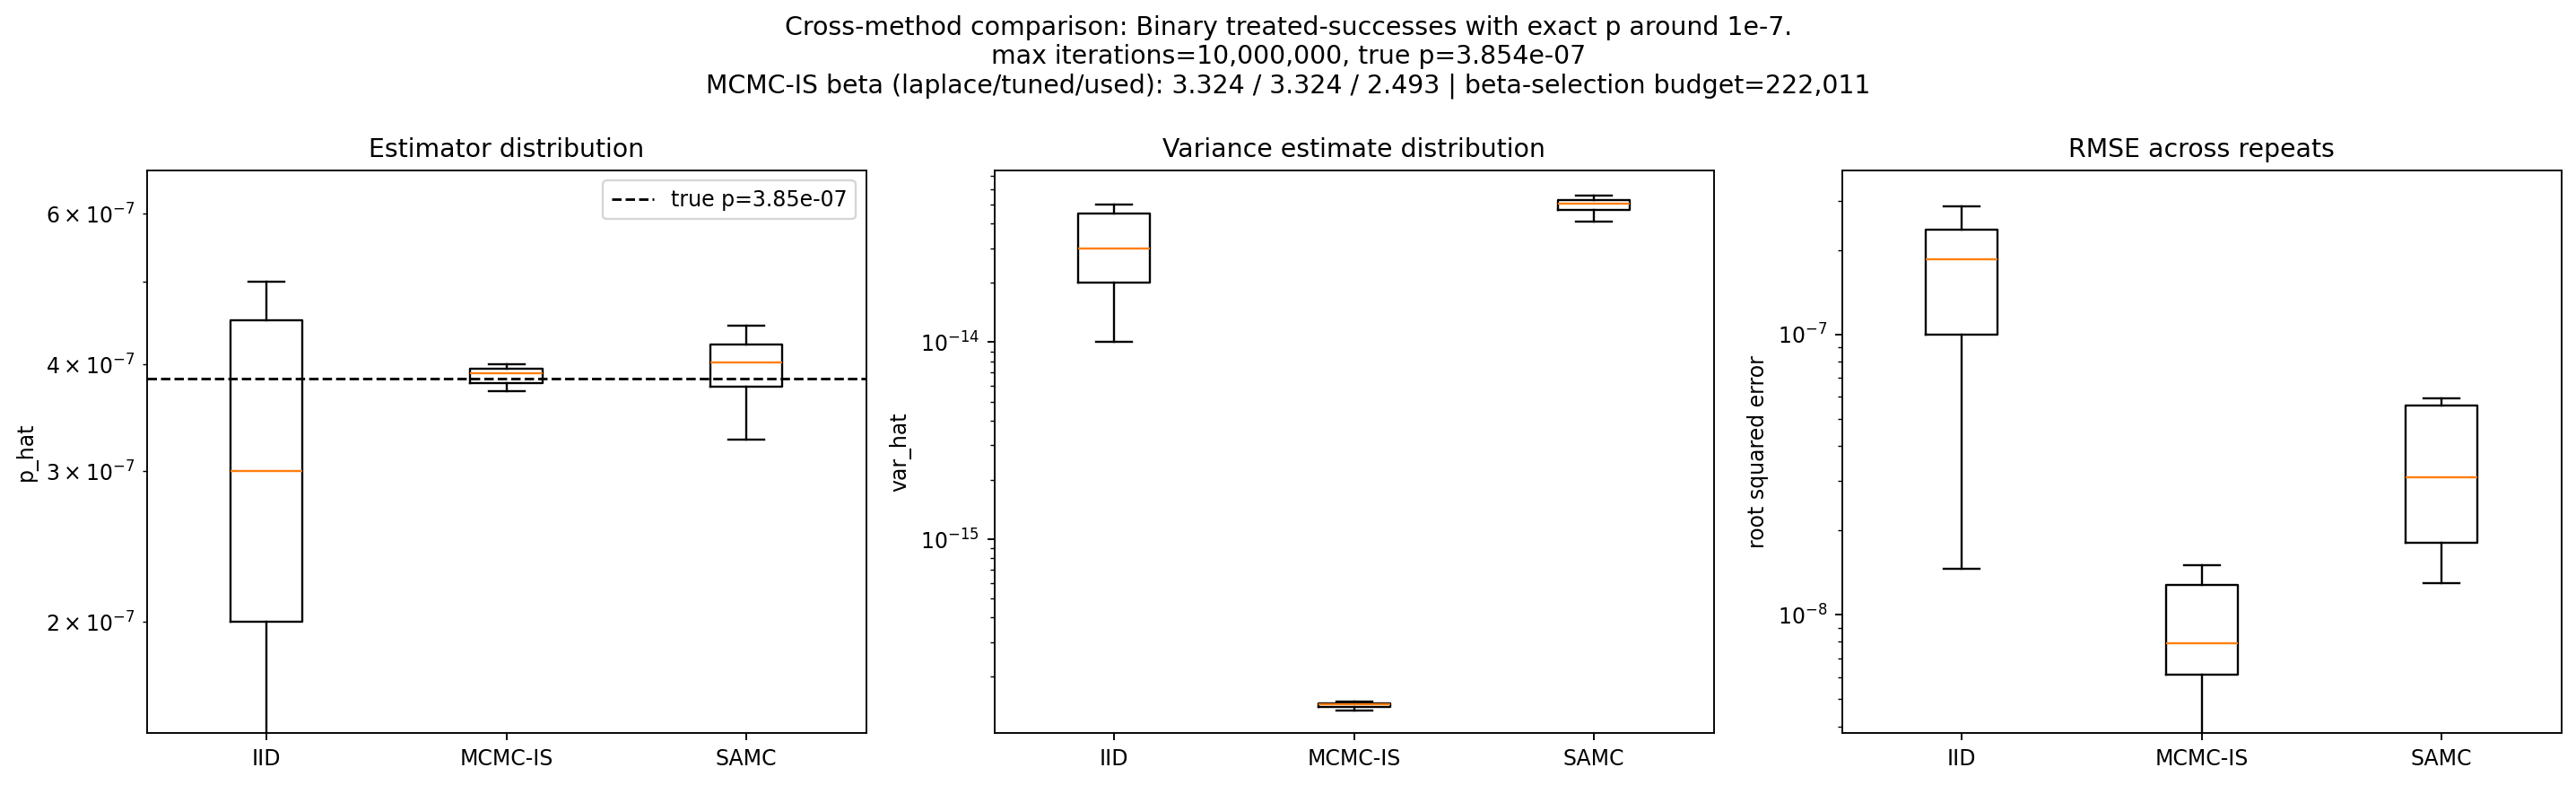

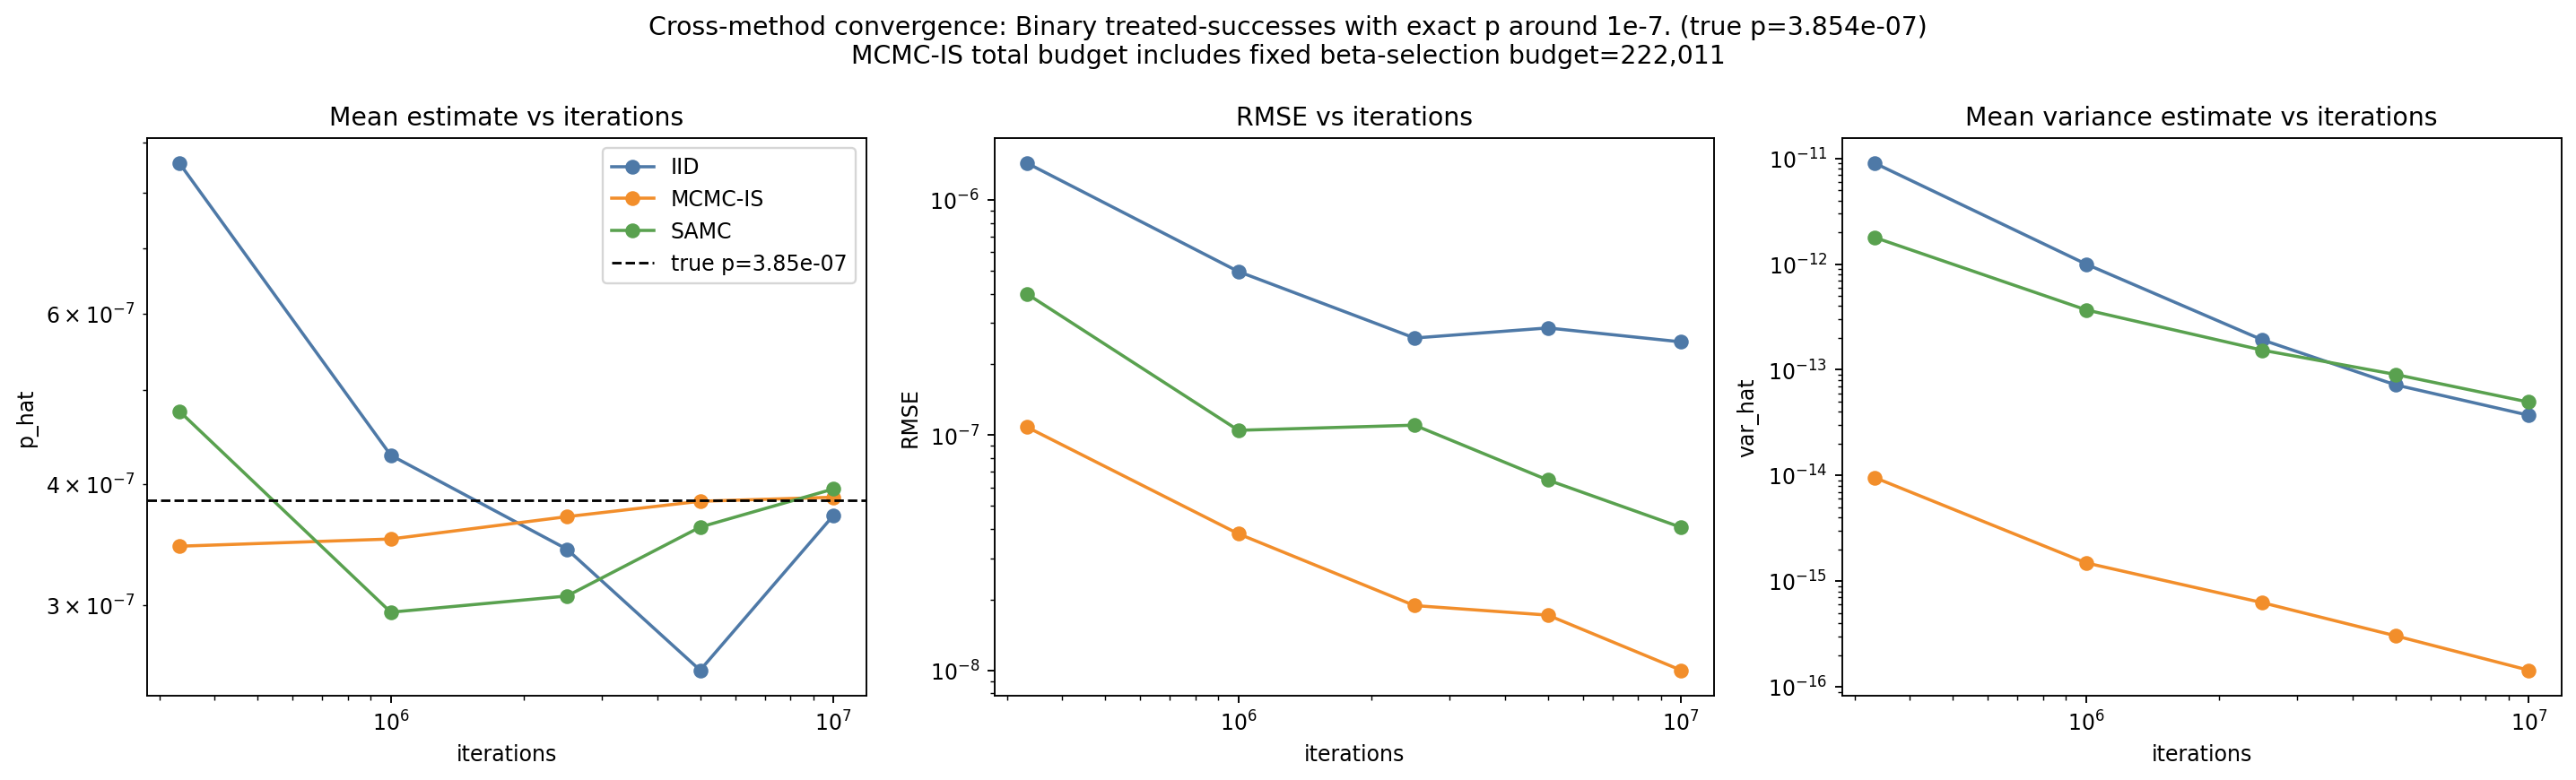

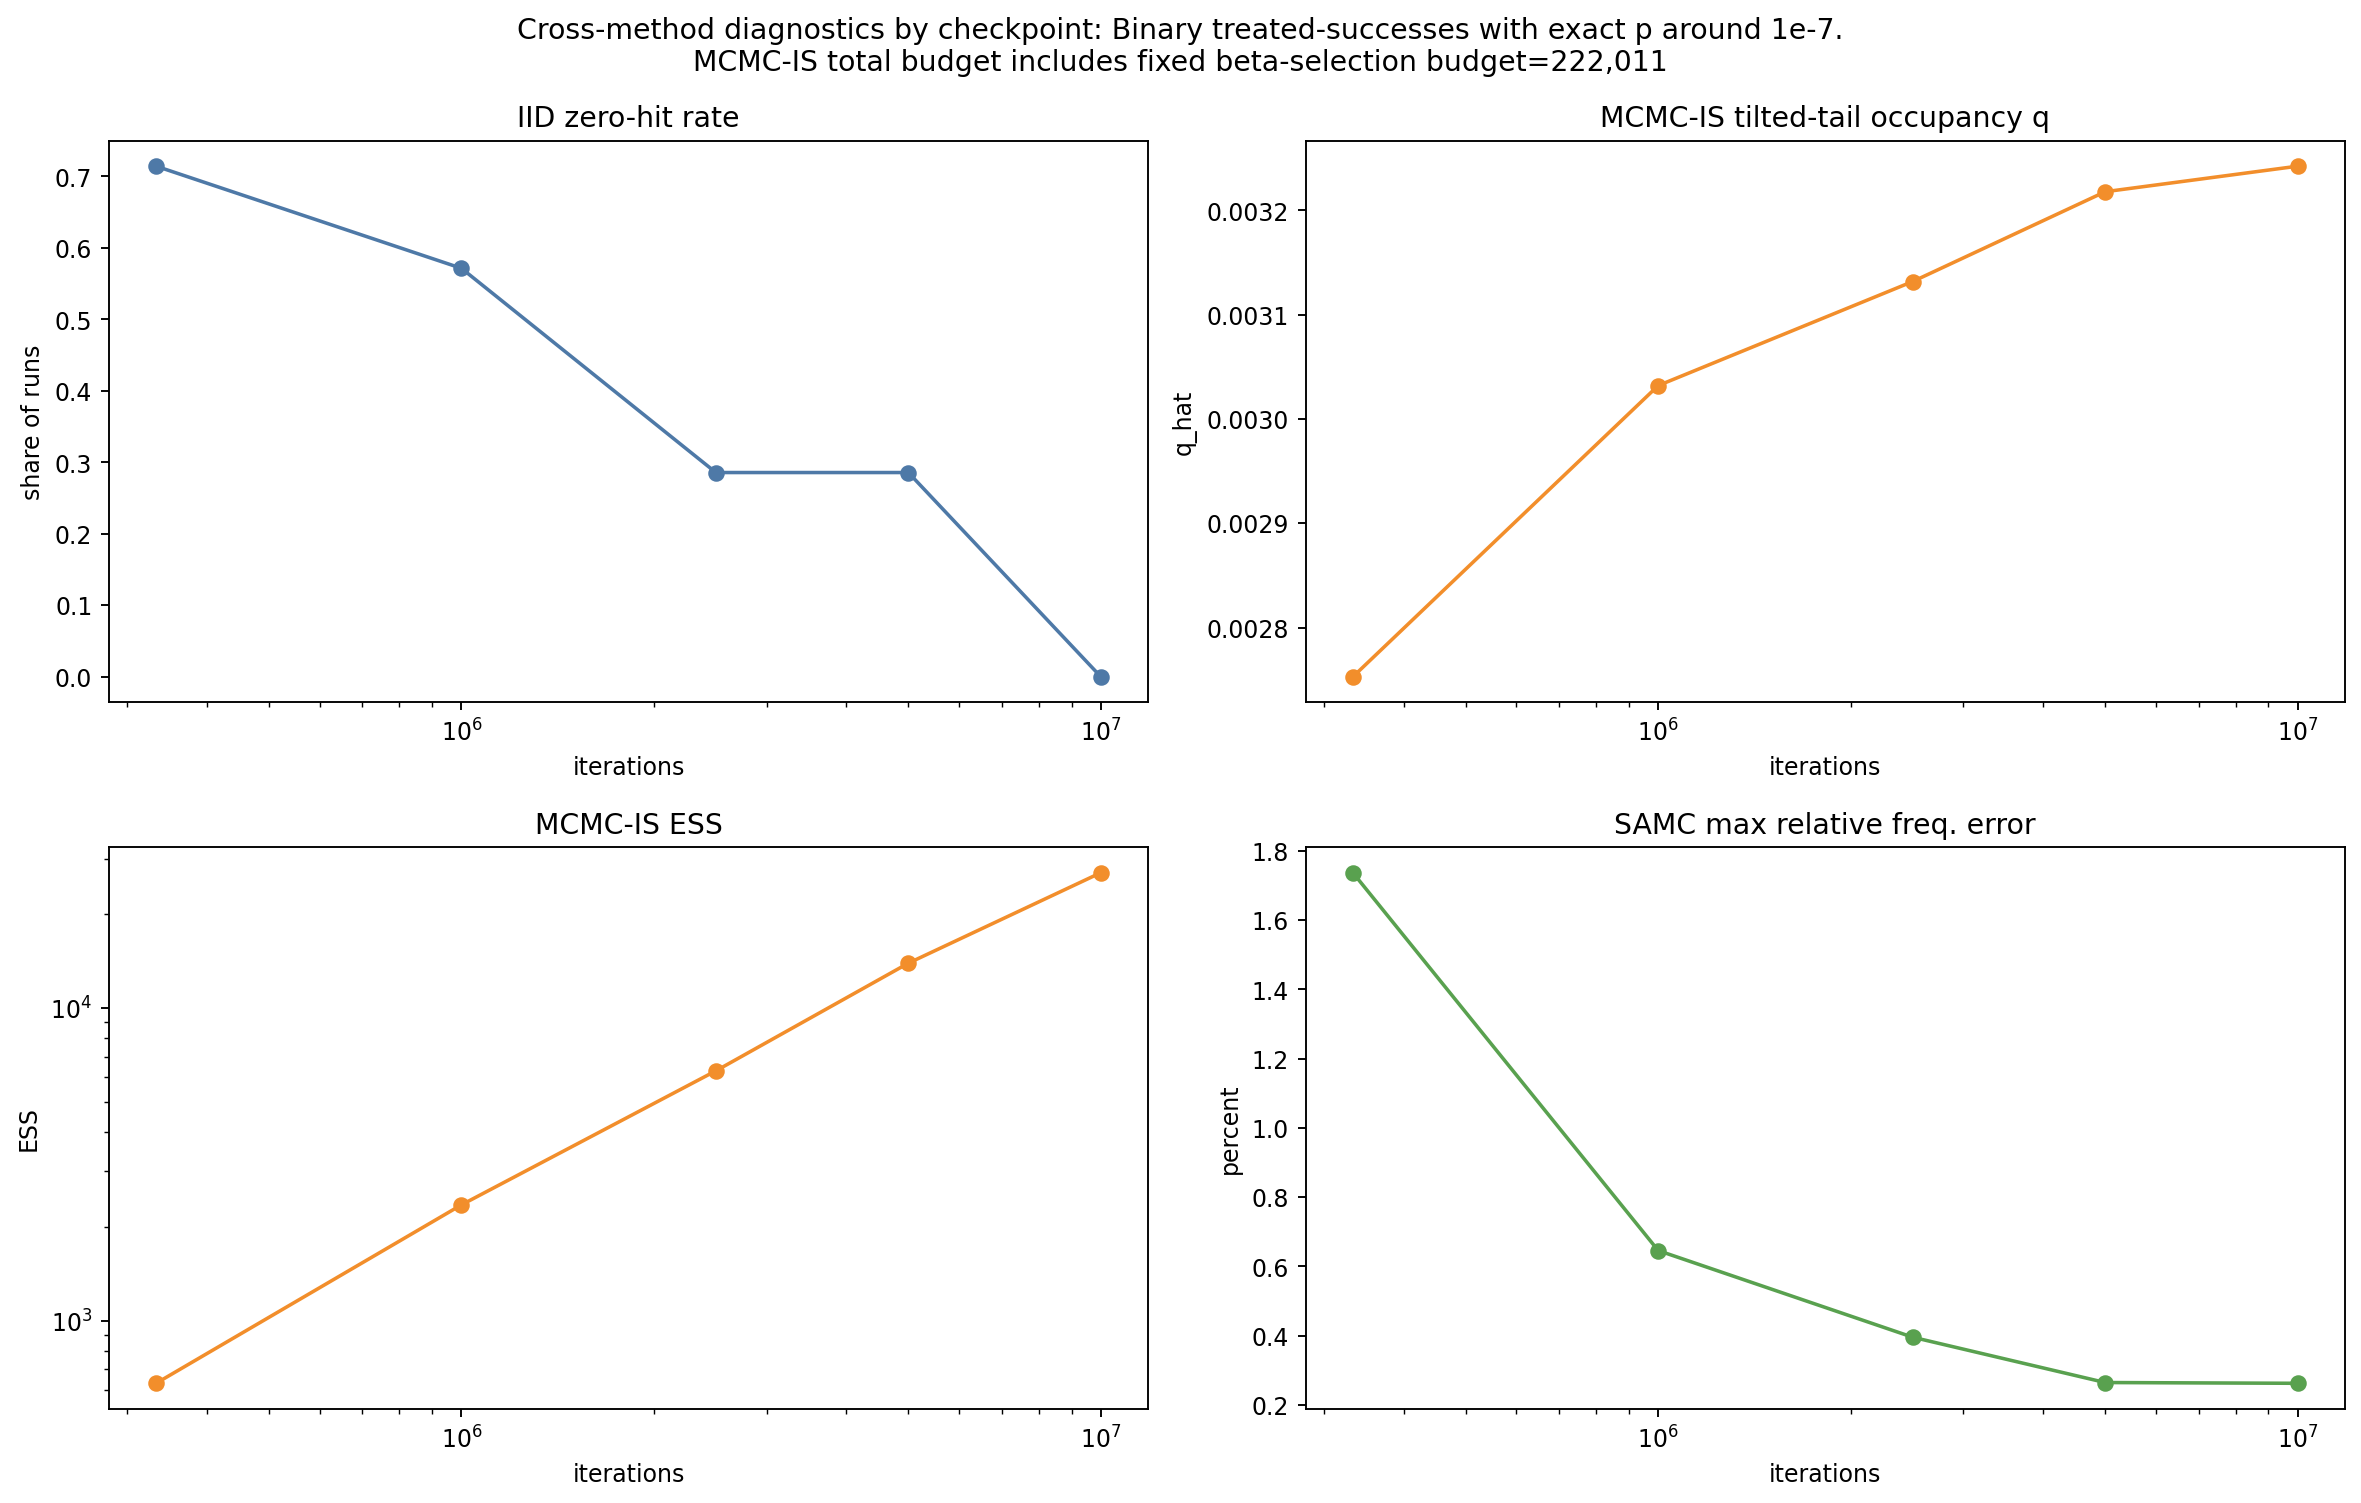

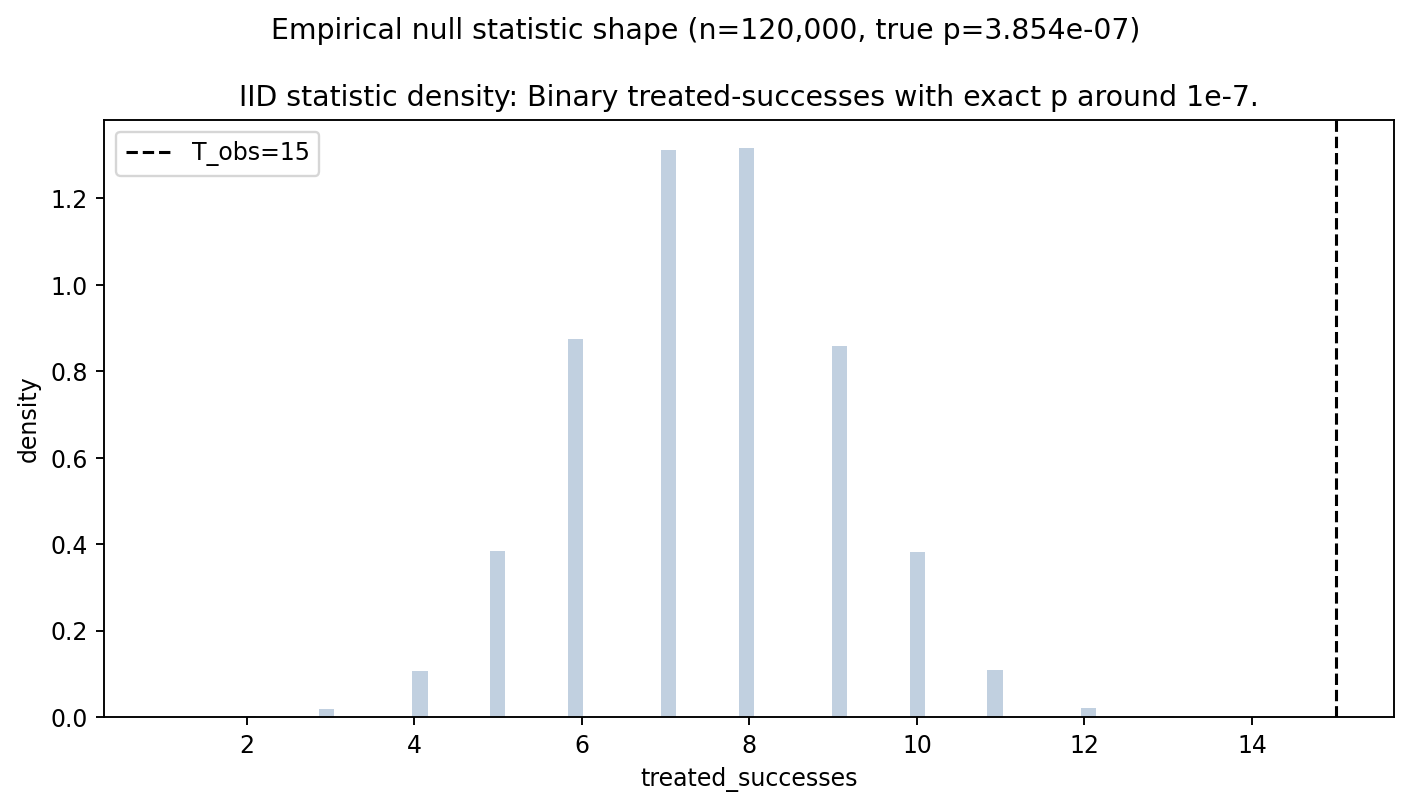


gwas_additive_score_n40


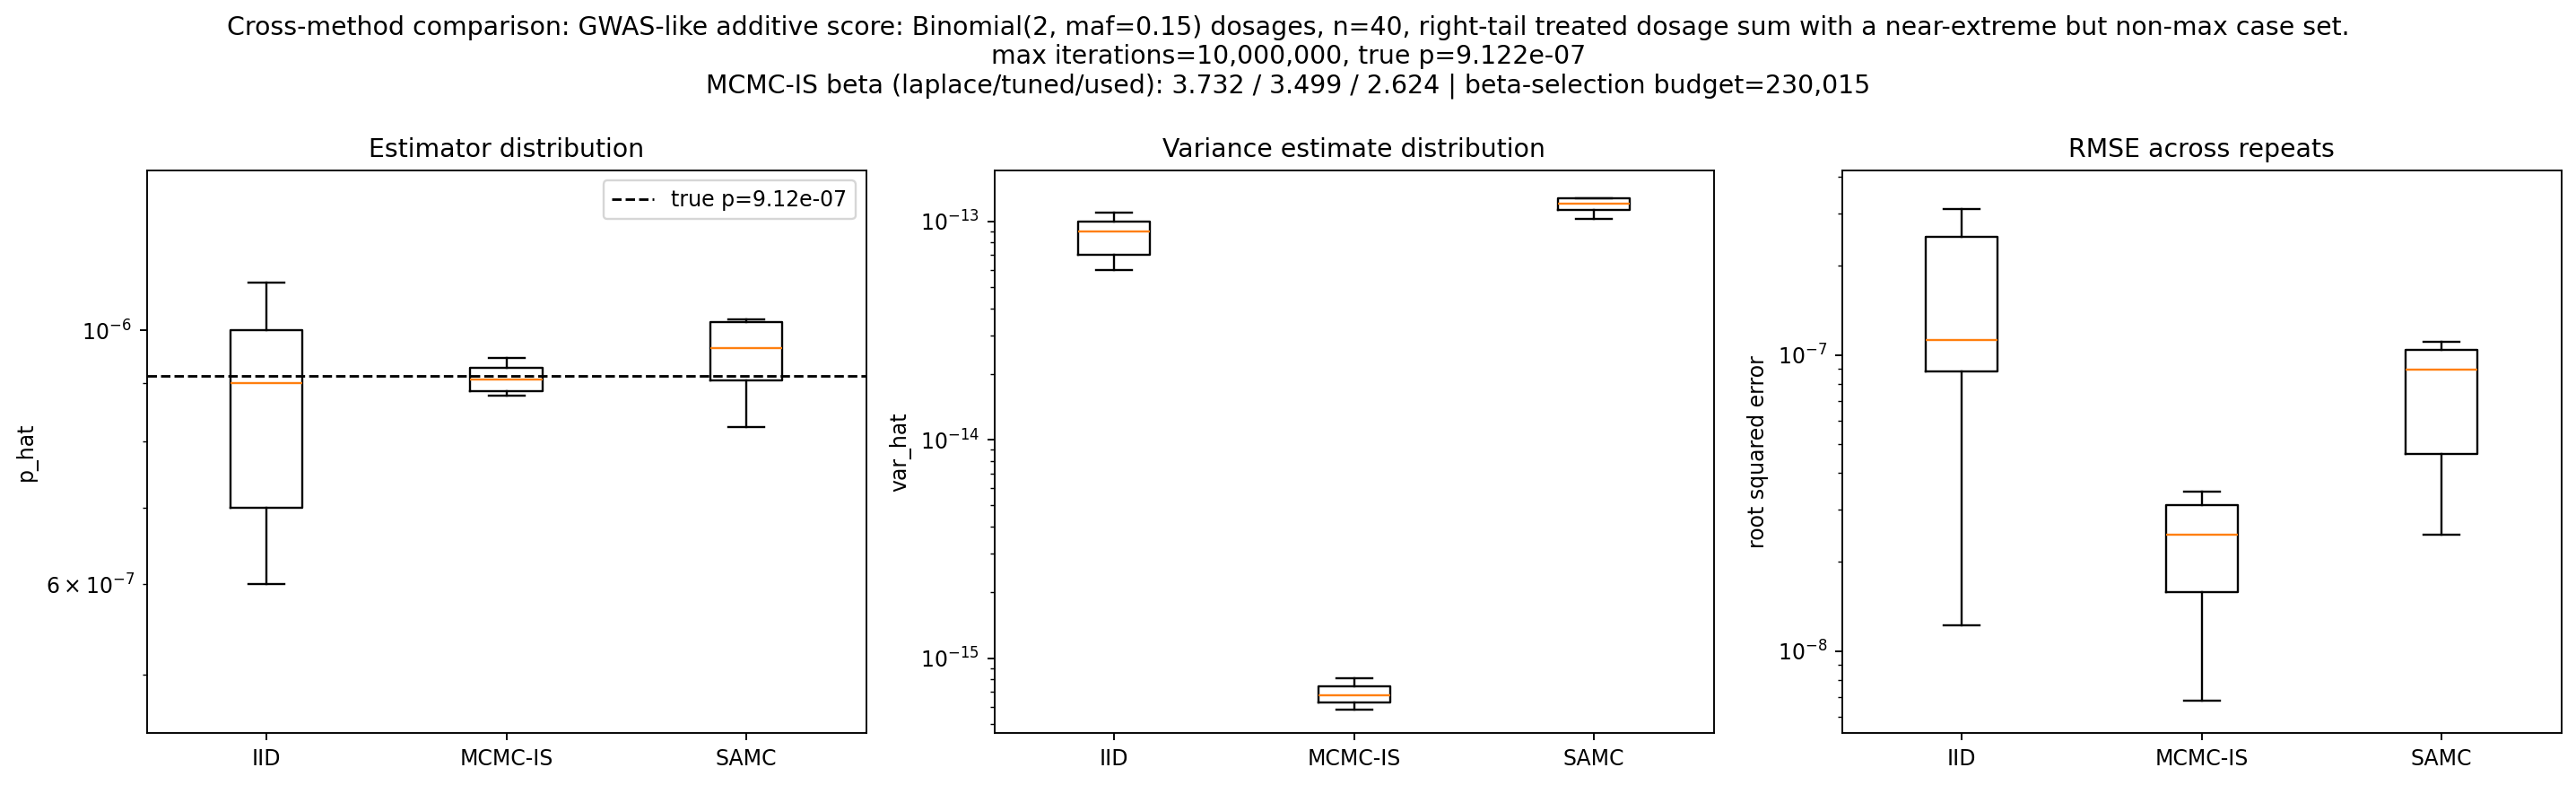

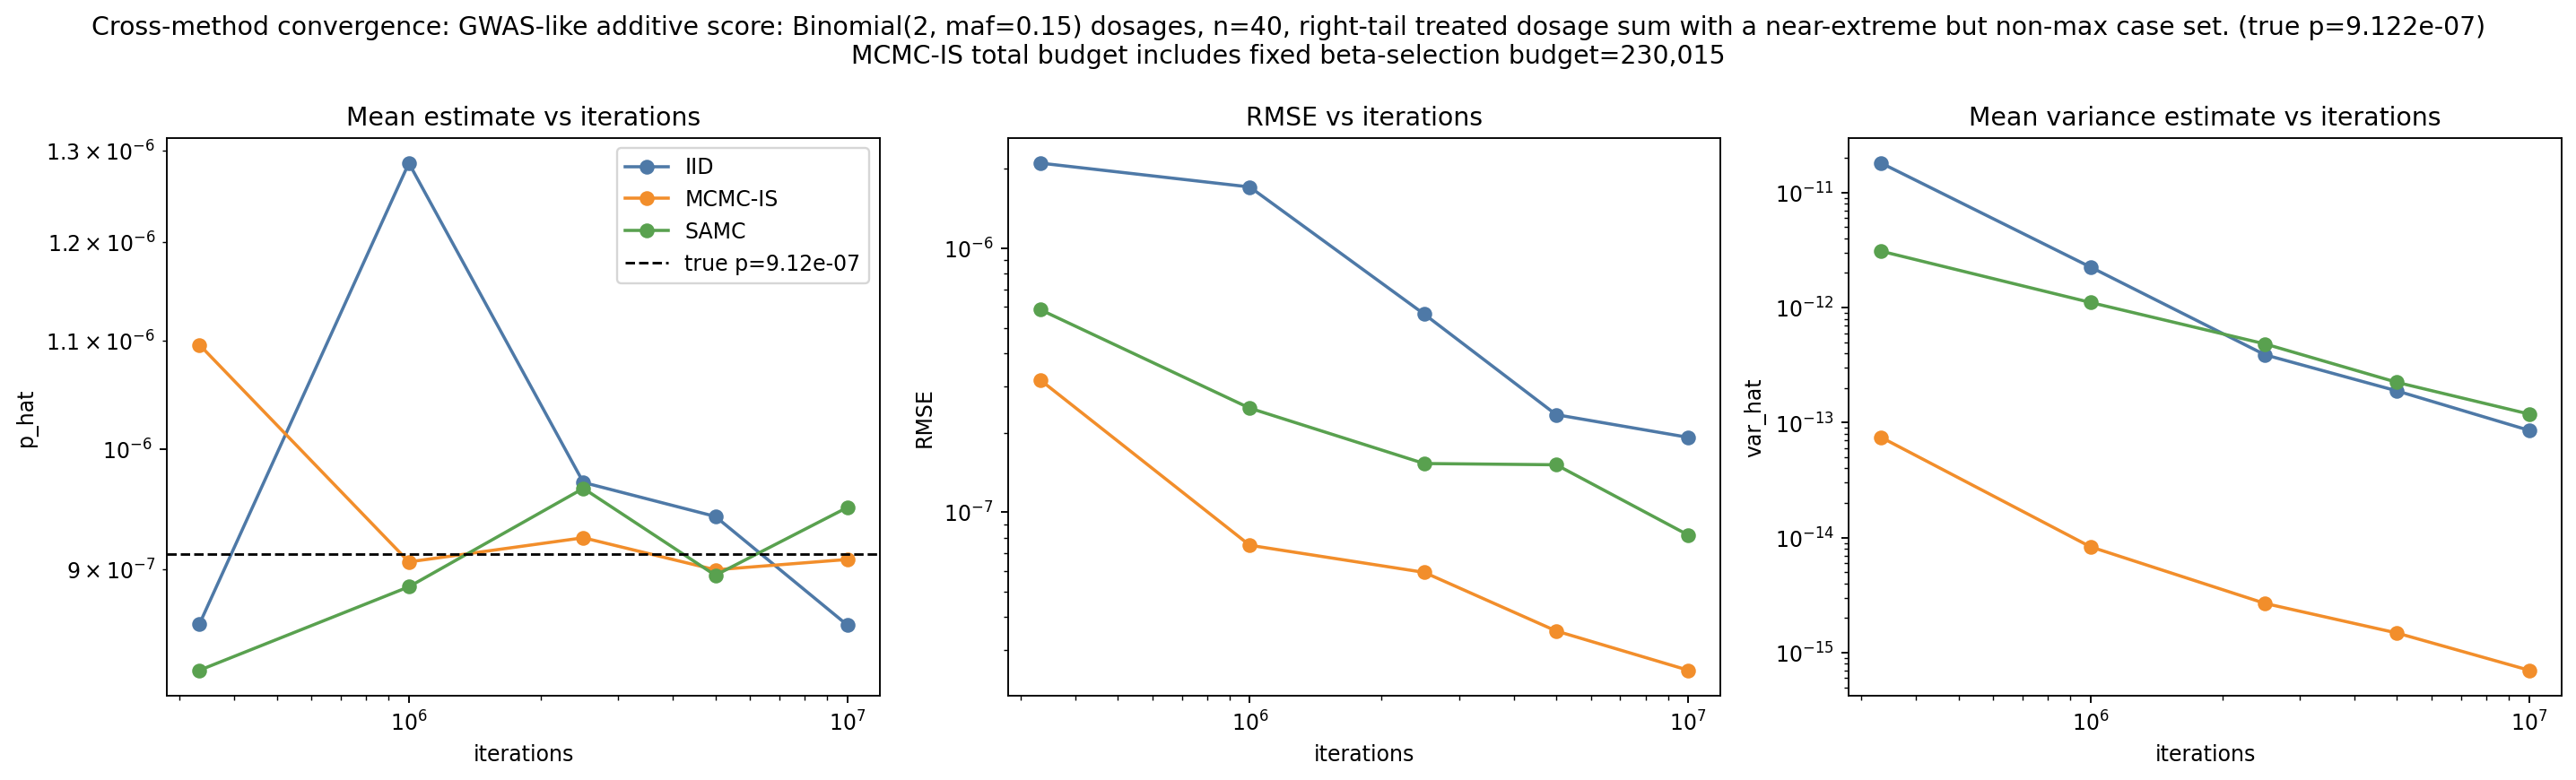

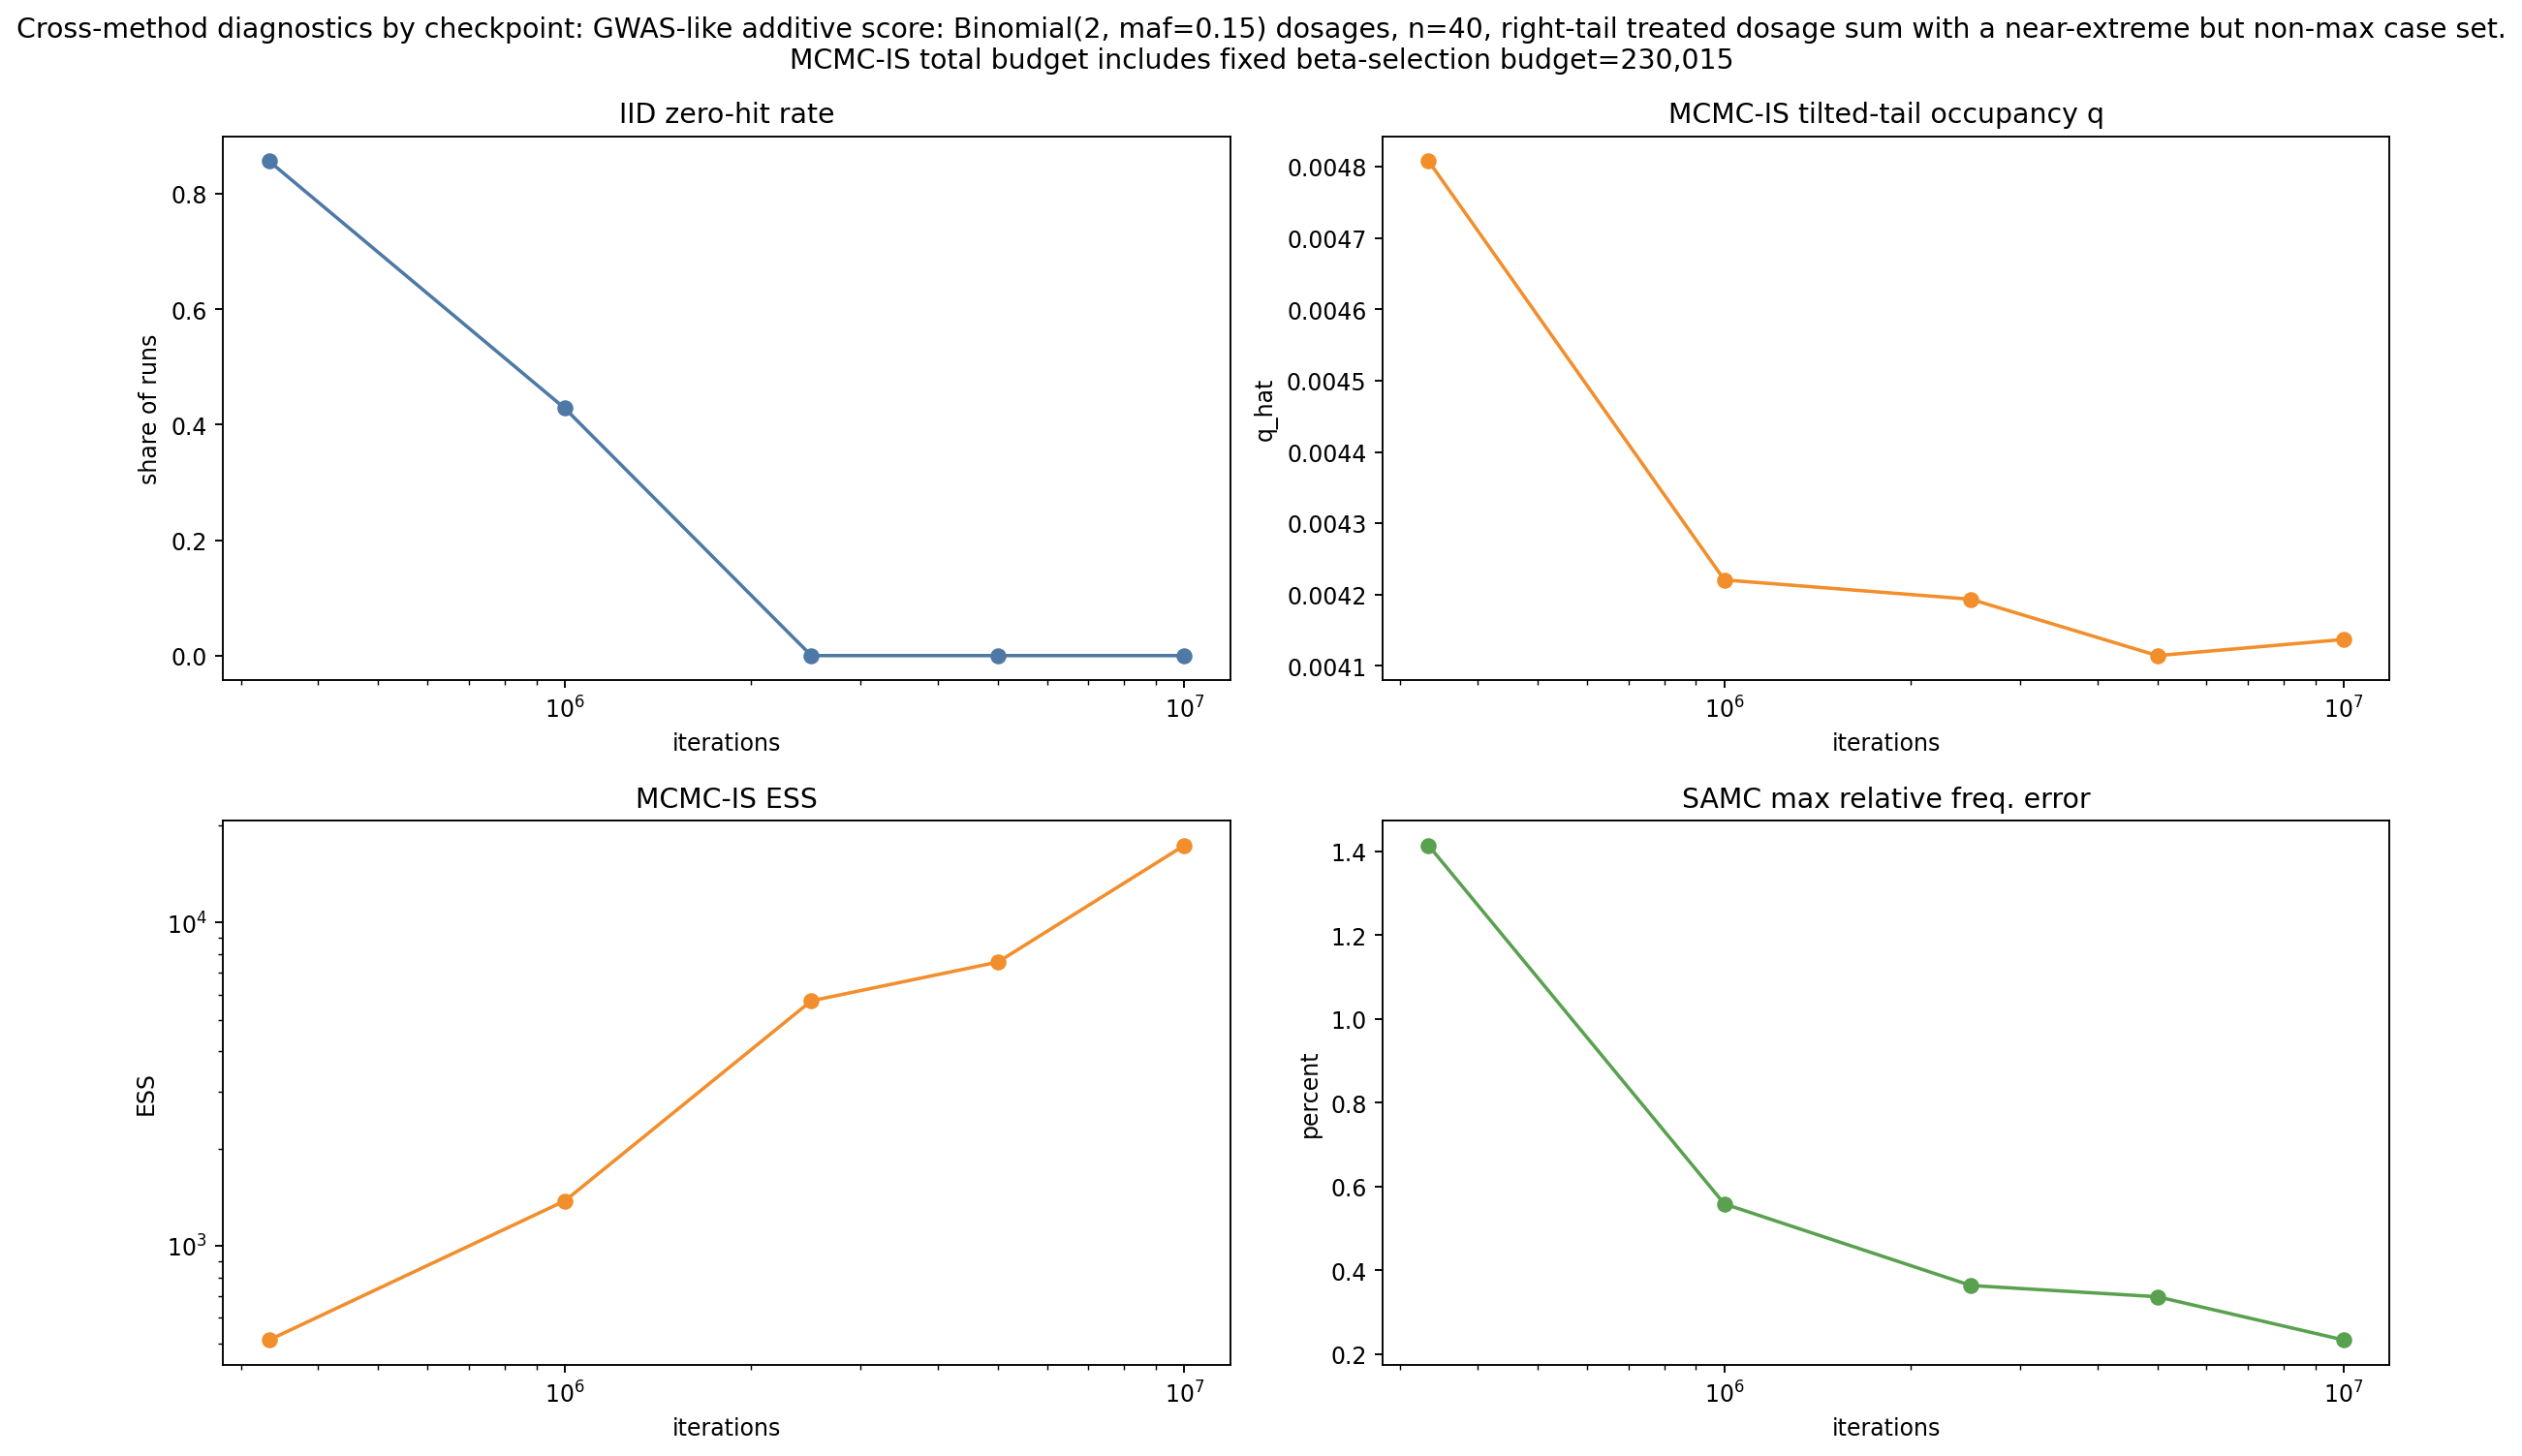

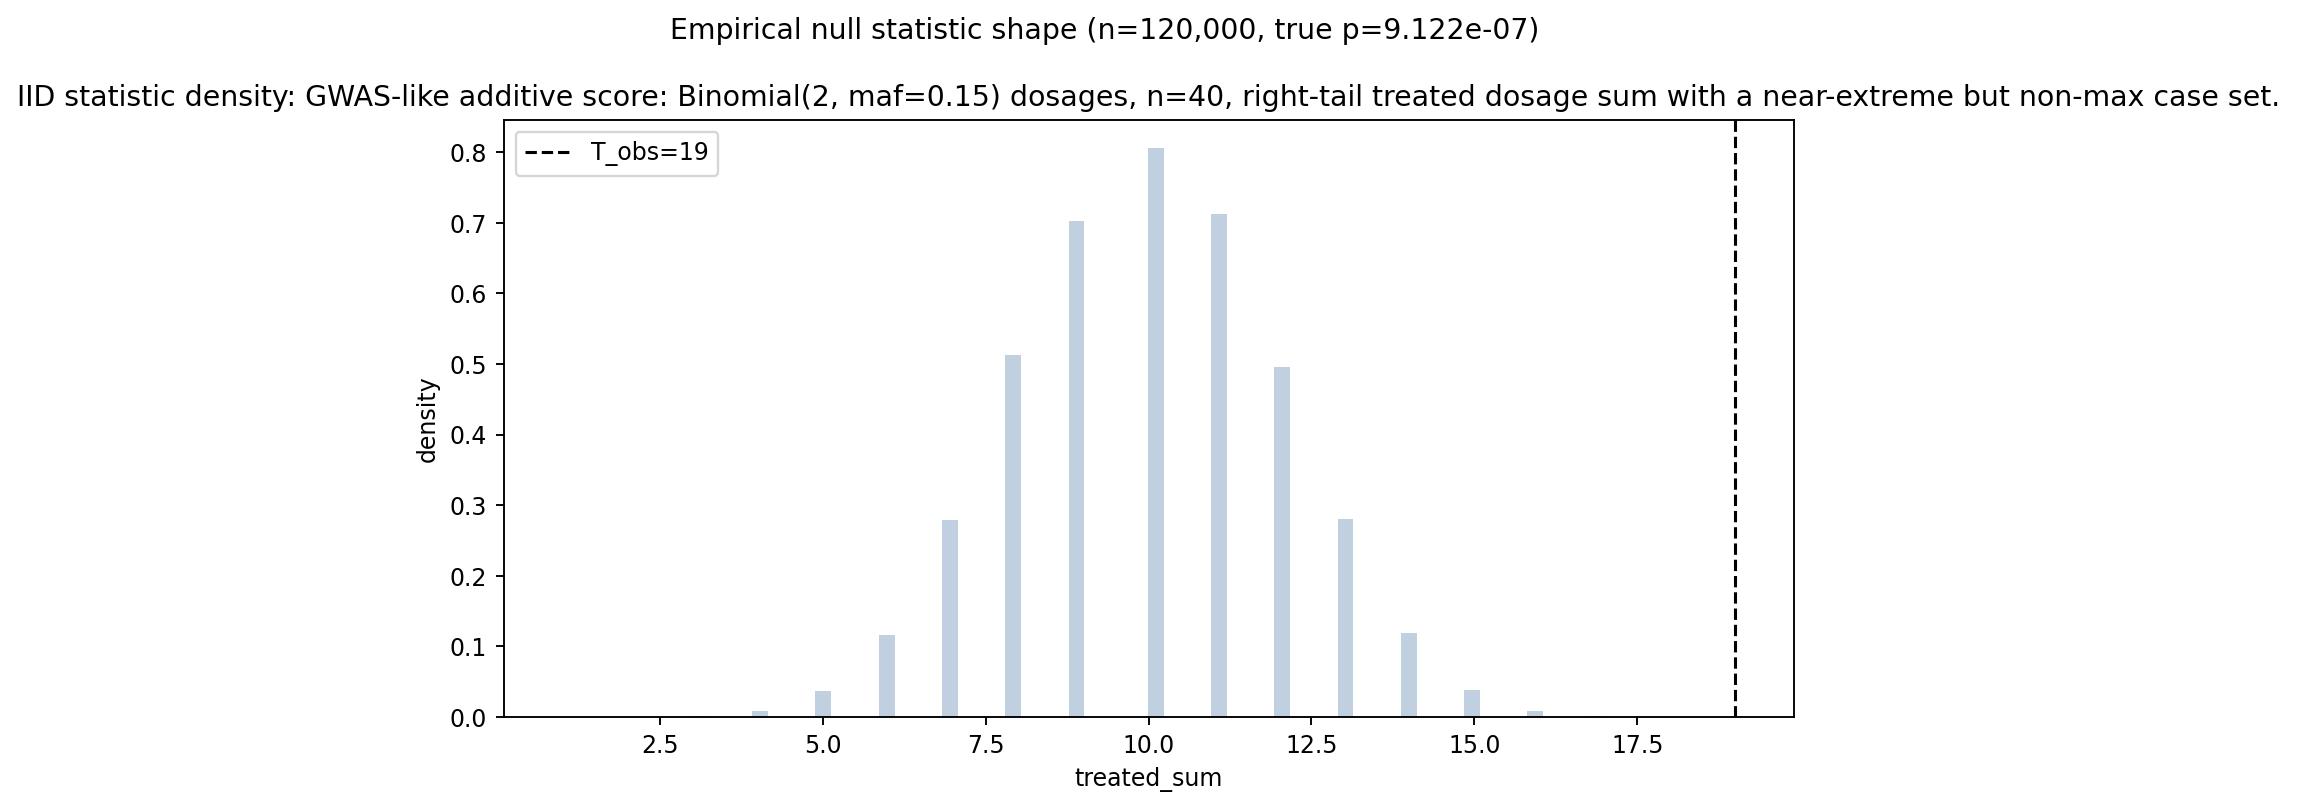


linear_stat_dp_n40


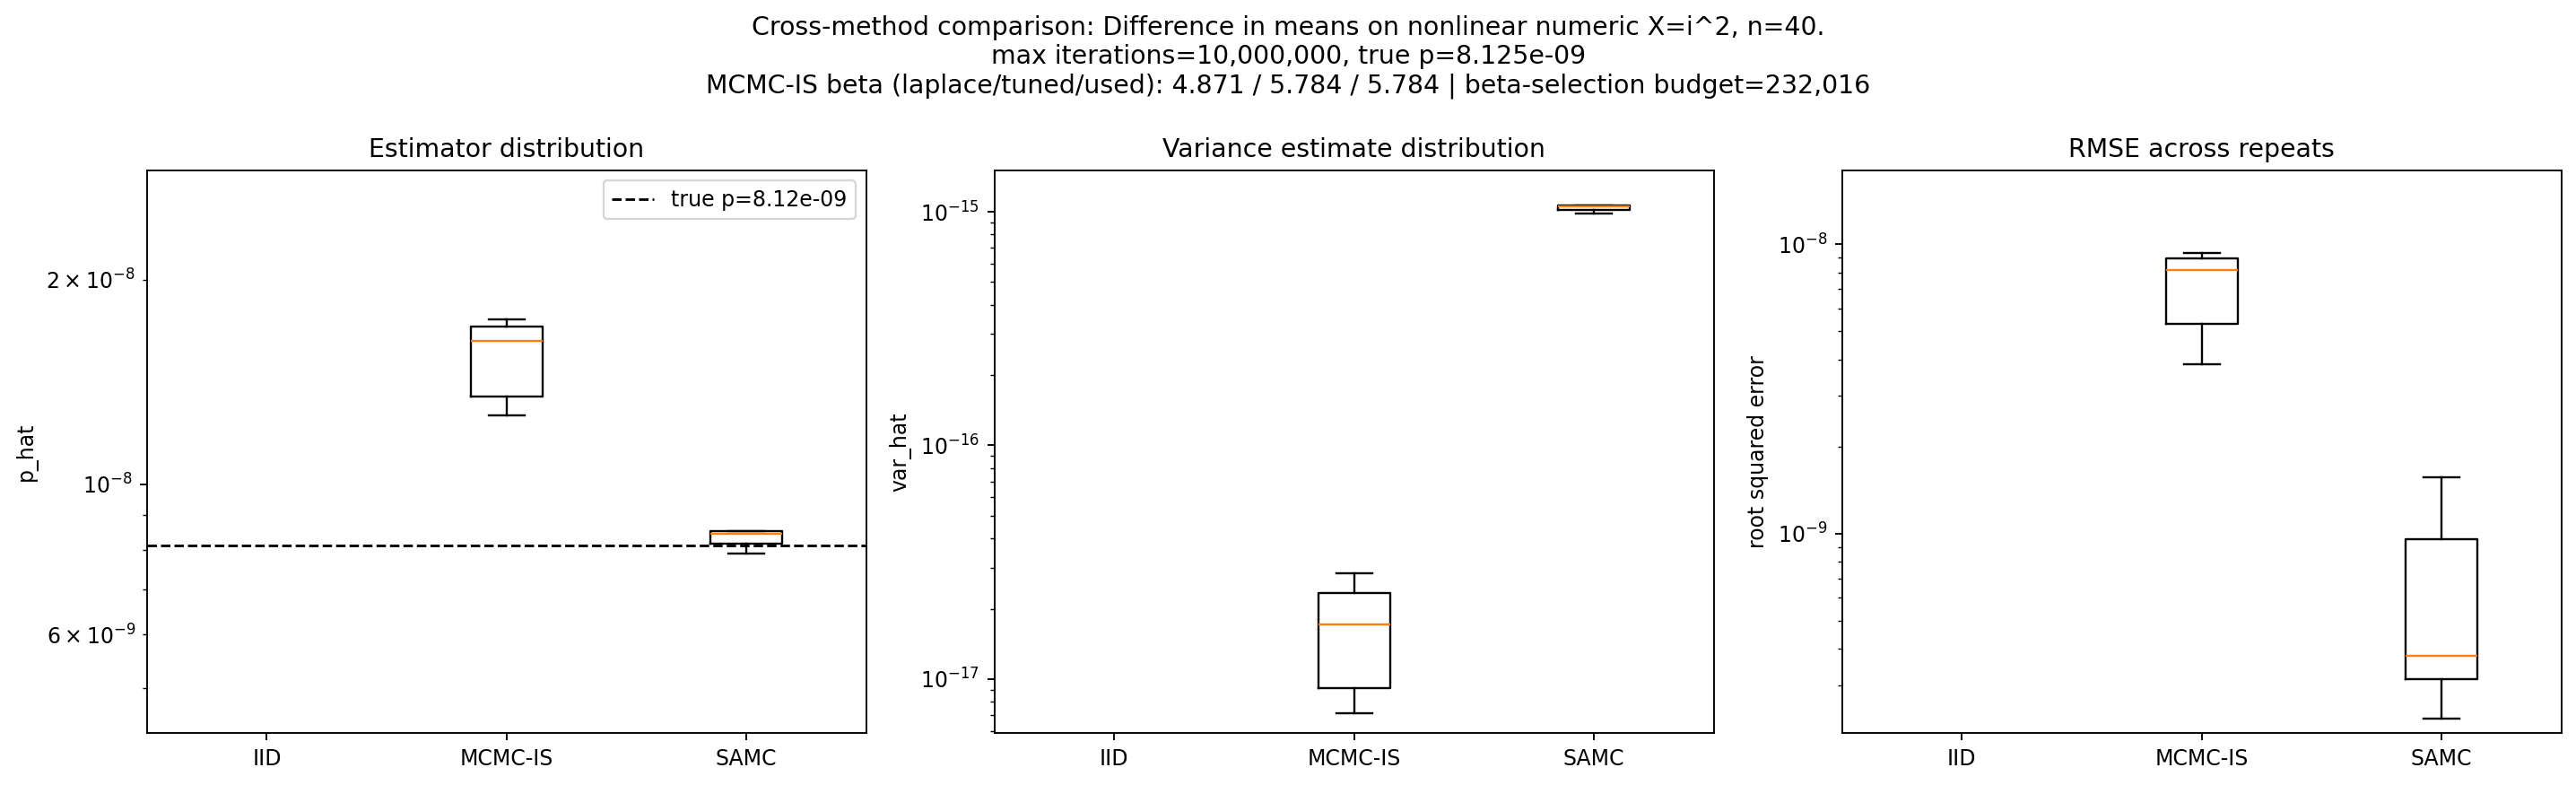

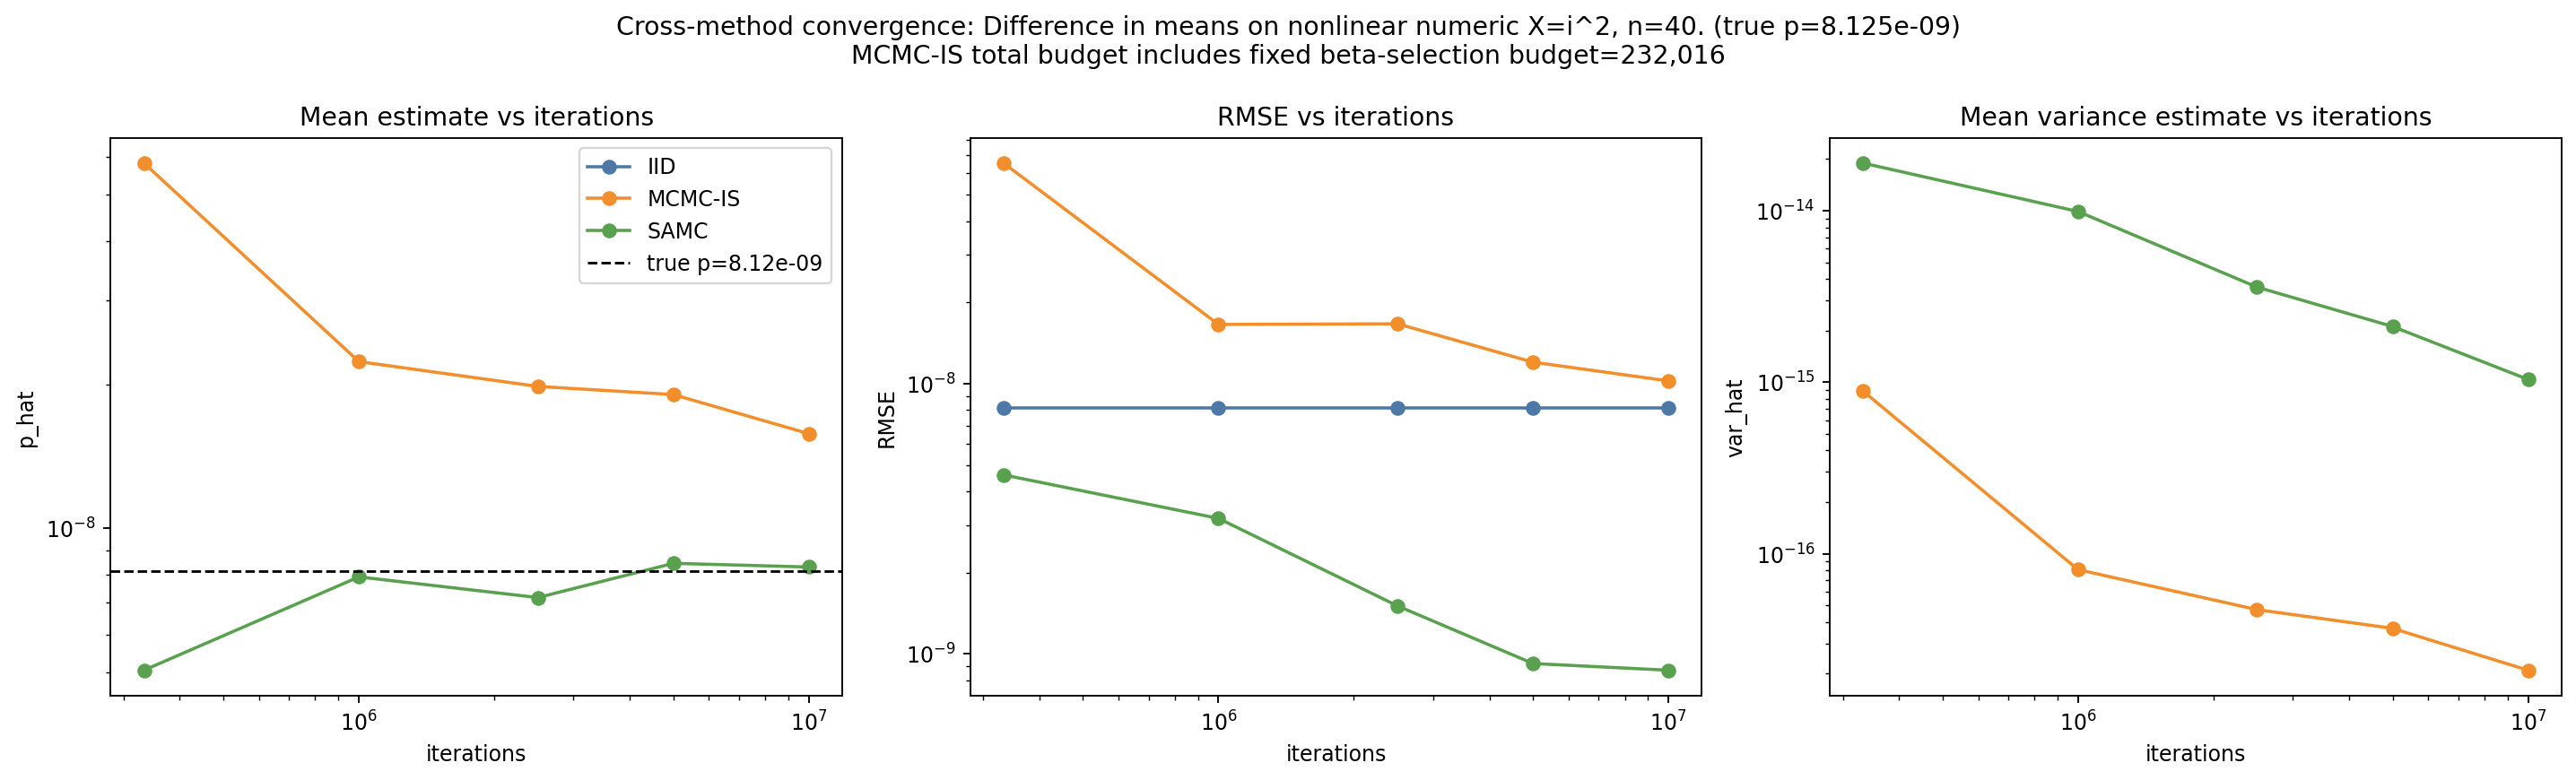

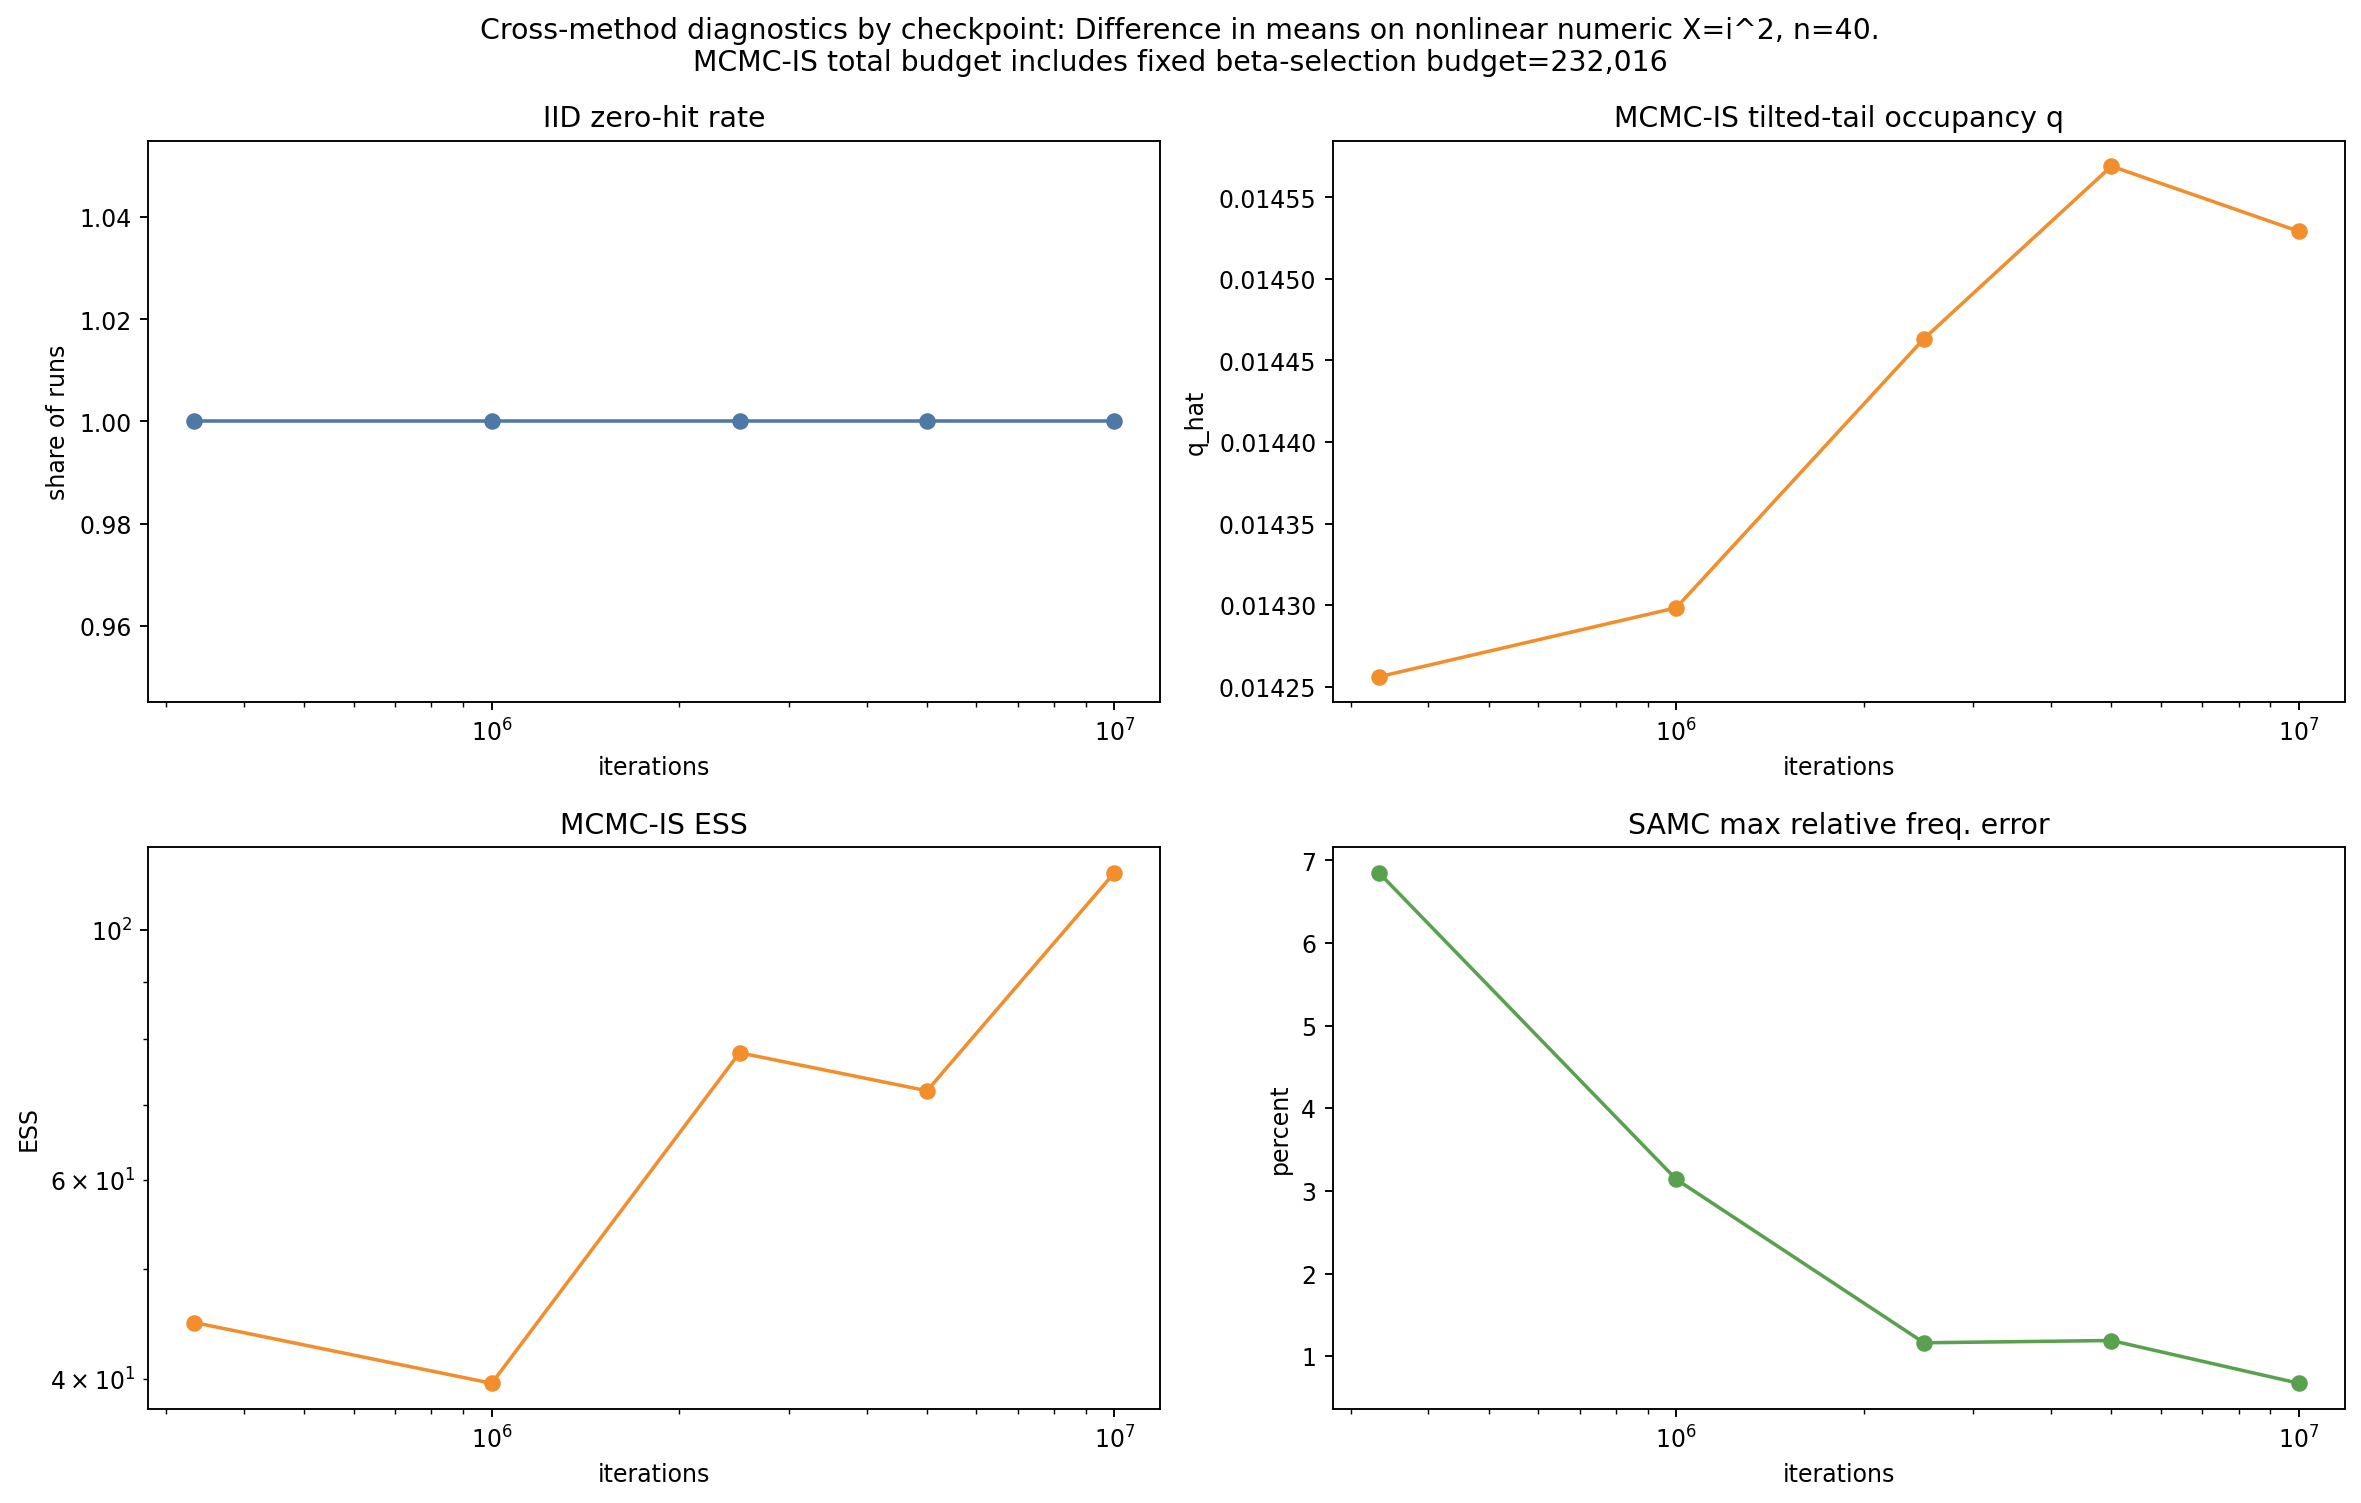

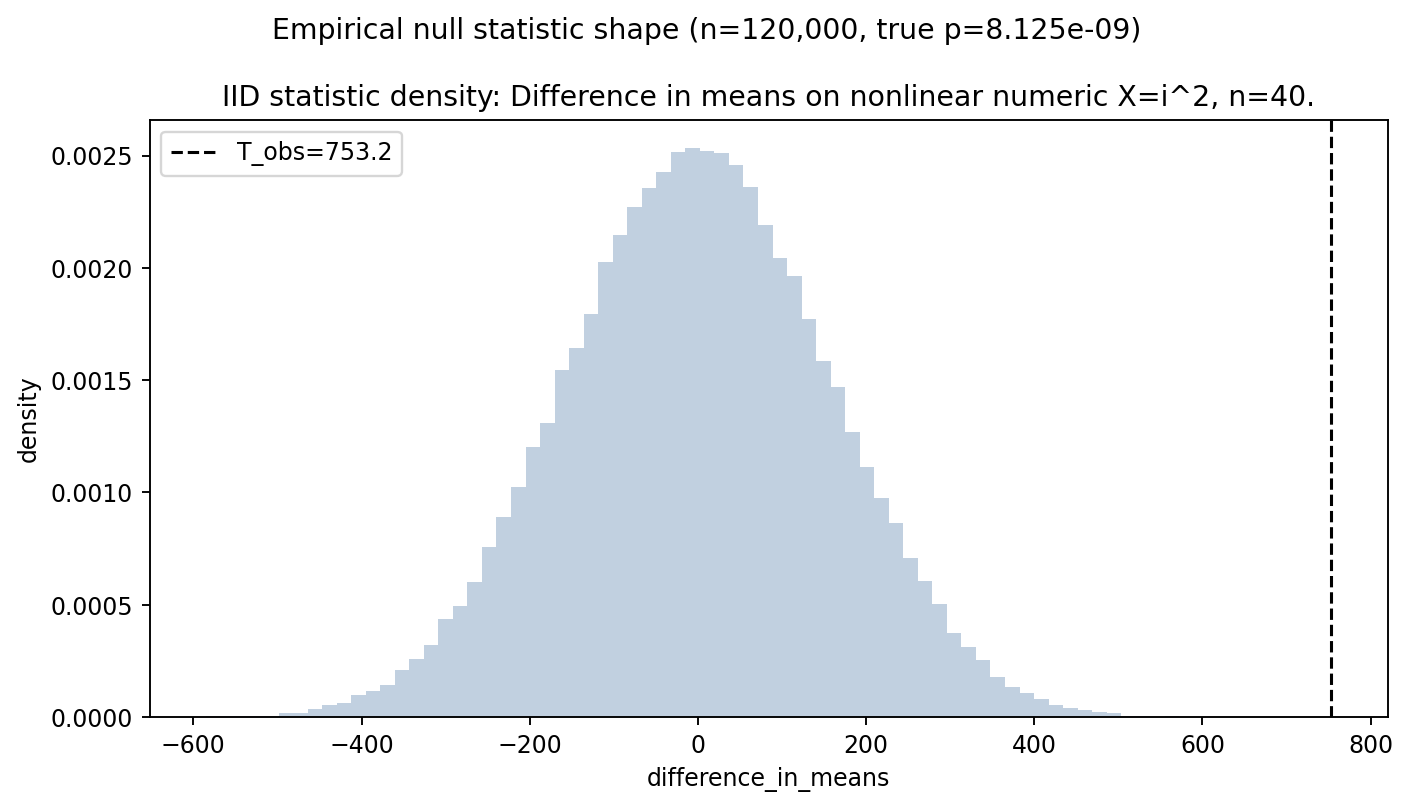


bruteforce_welch_nonextreme_n22


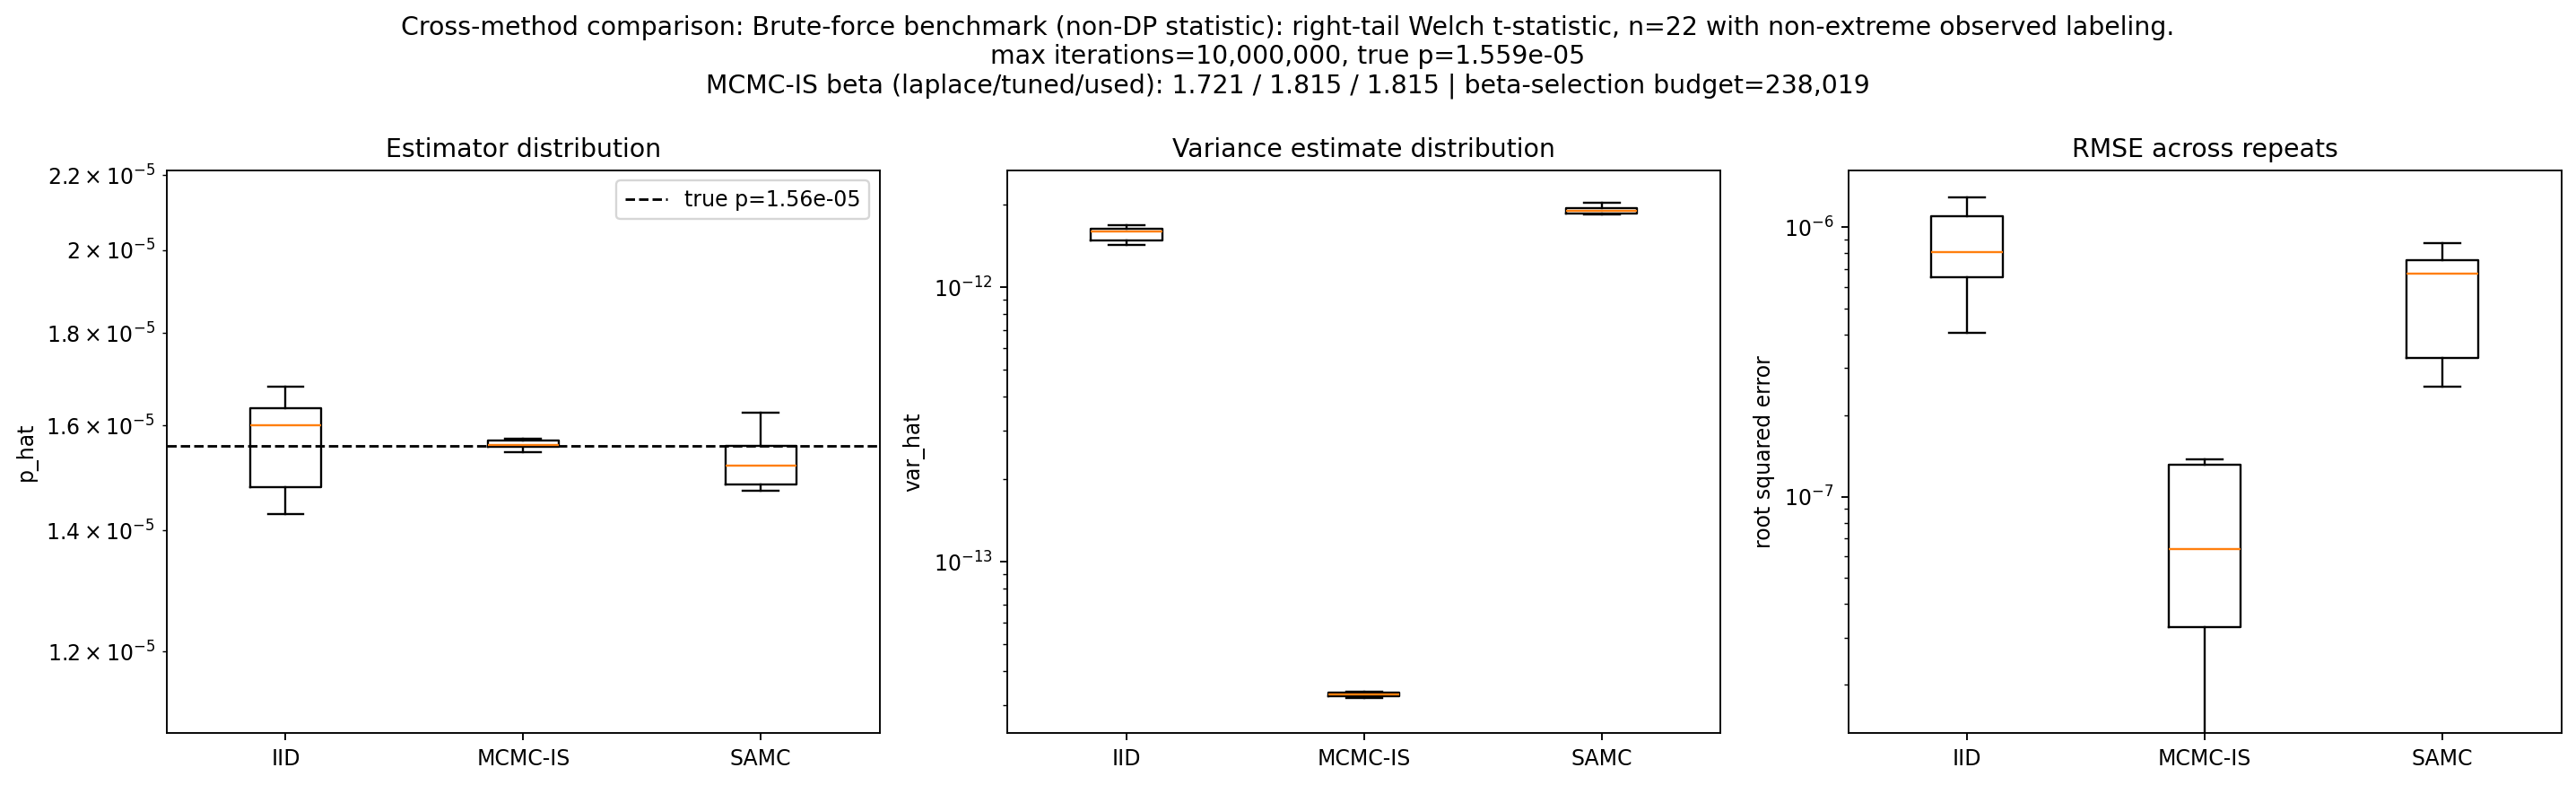

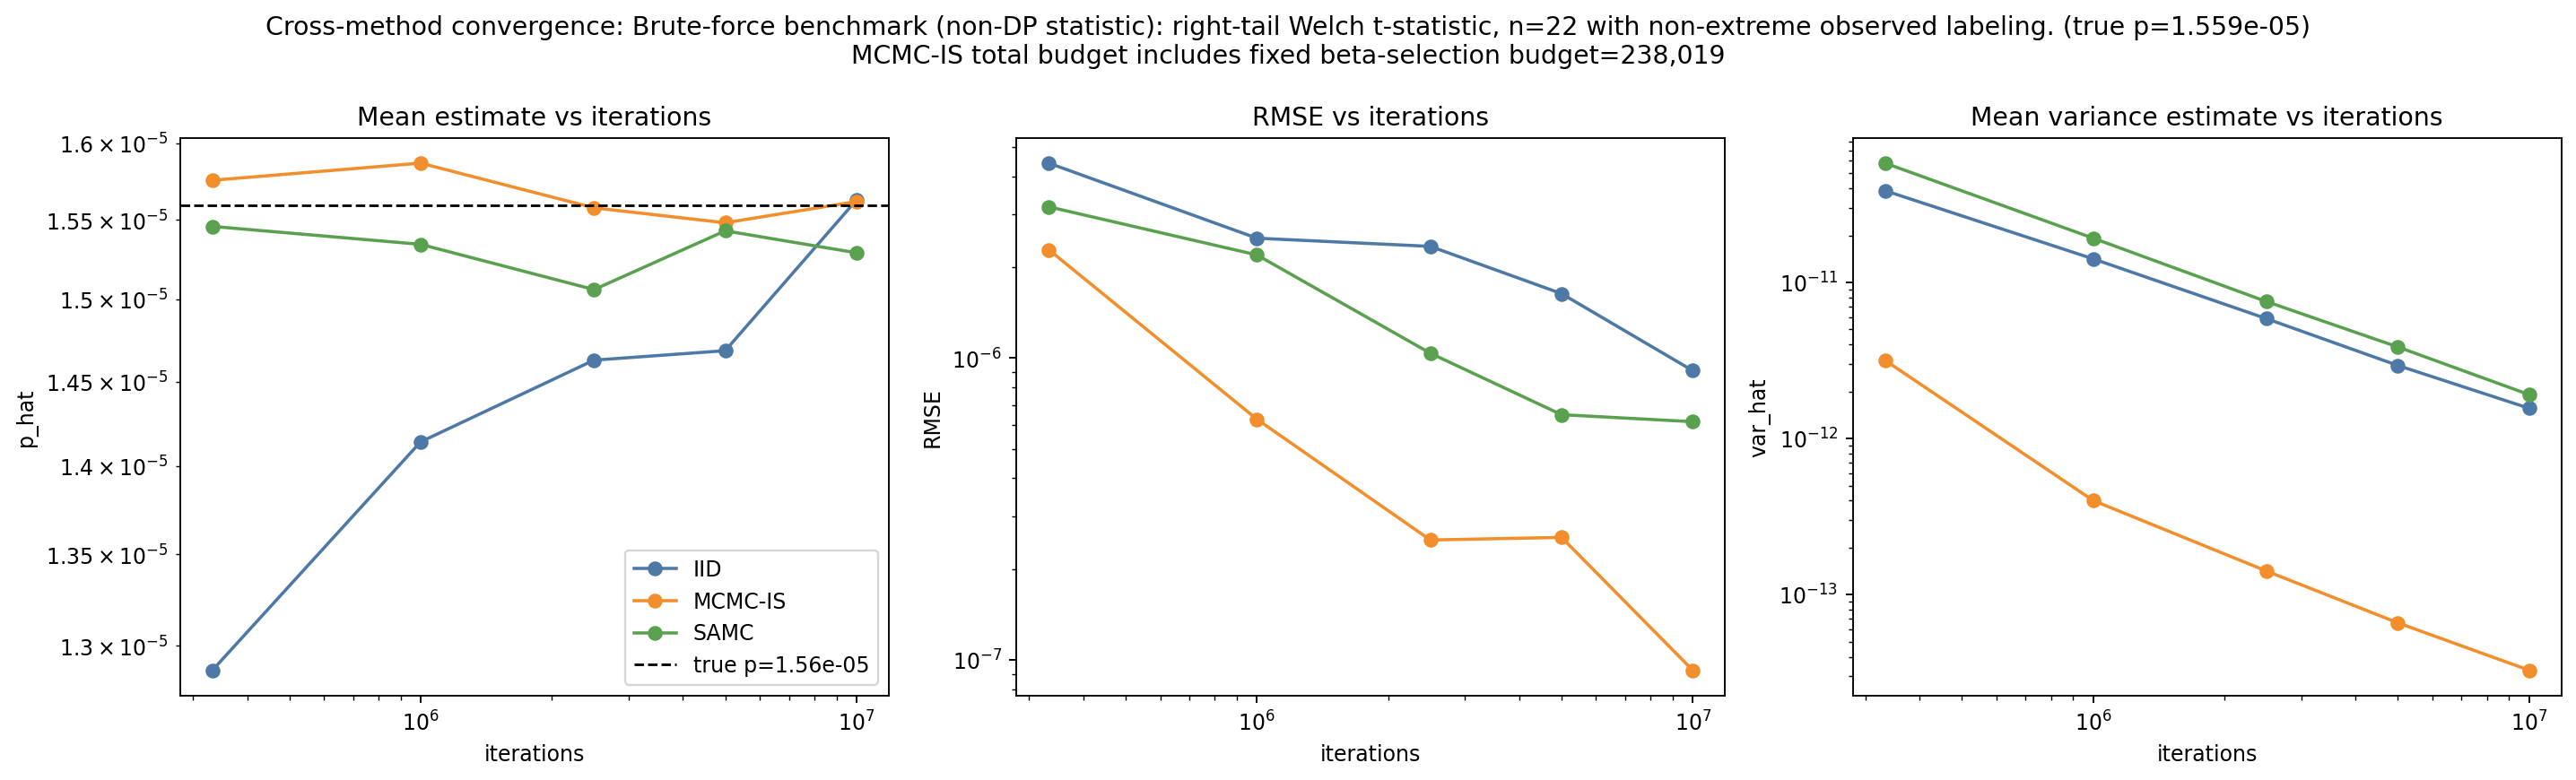

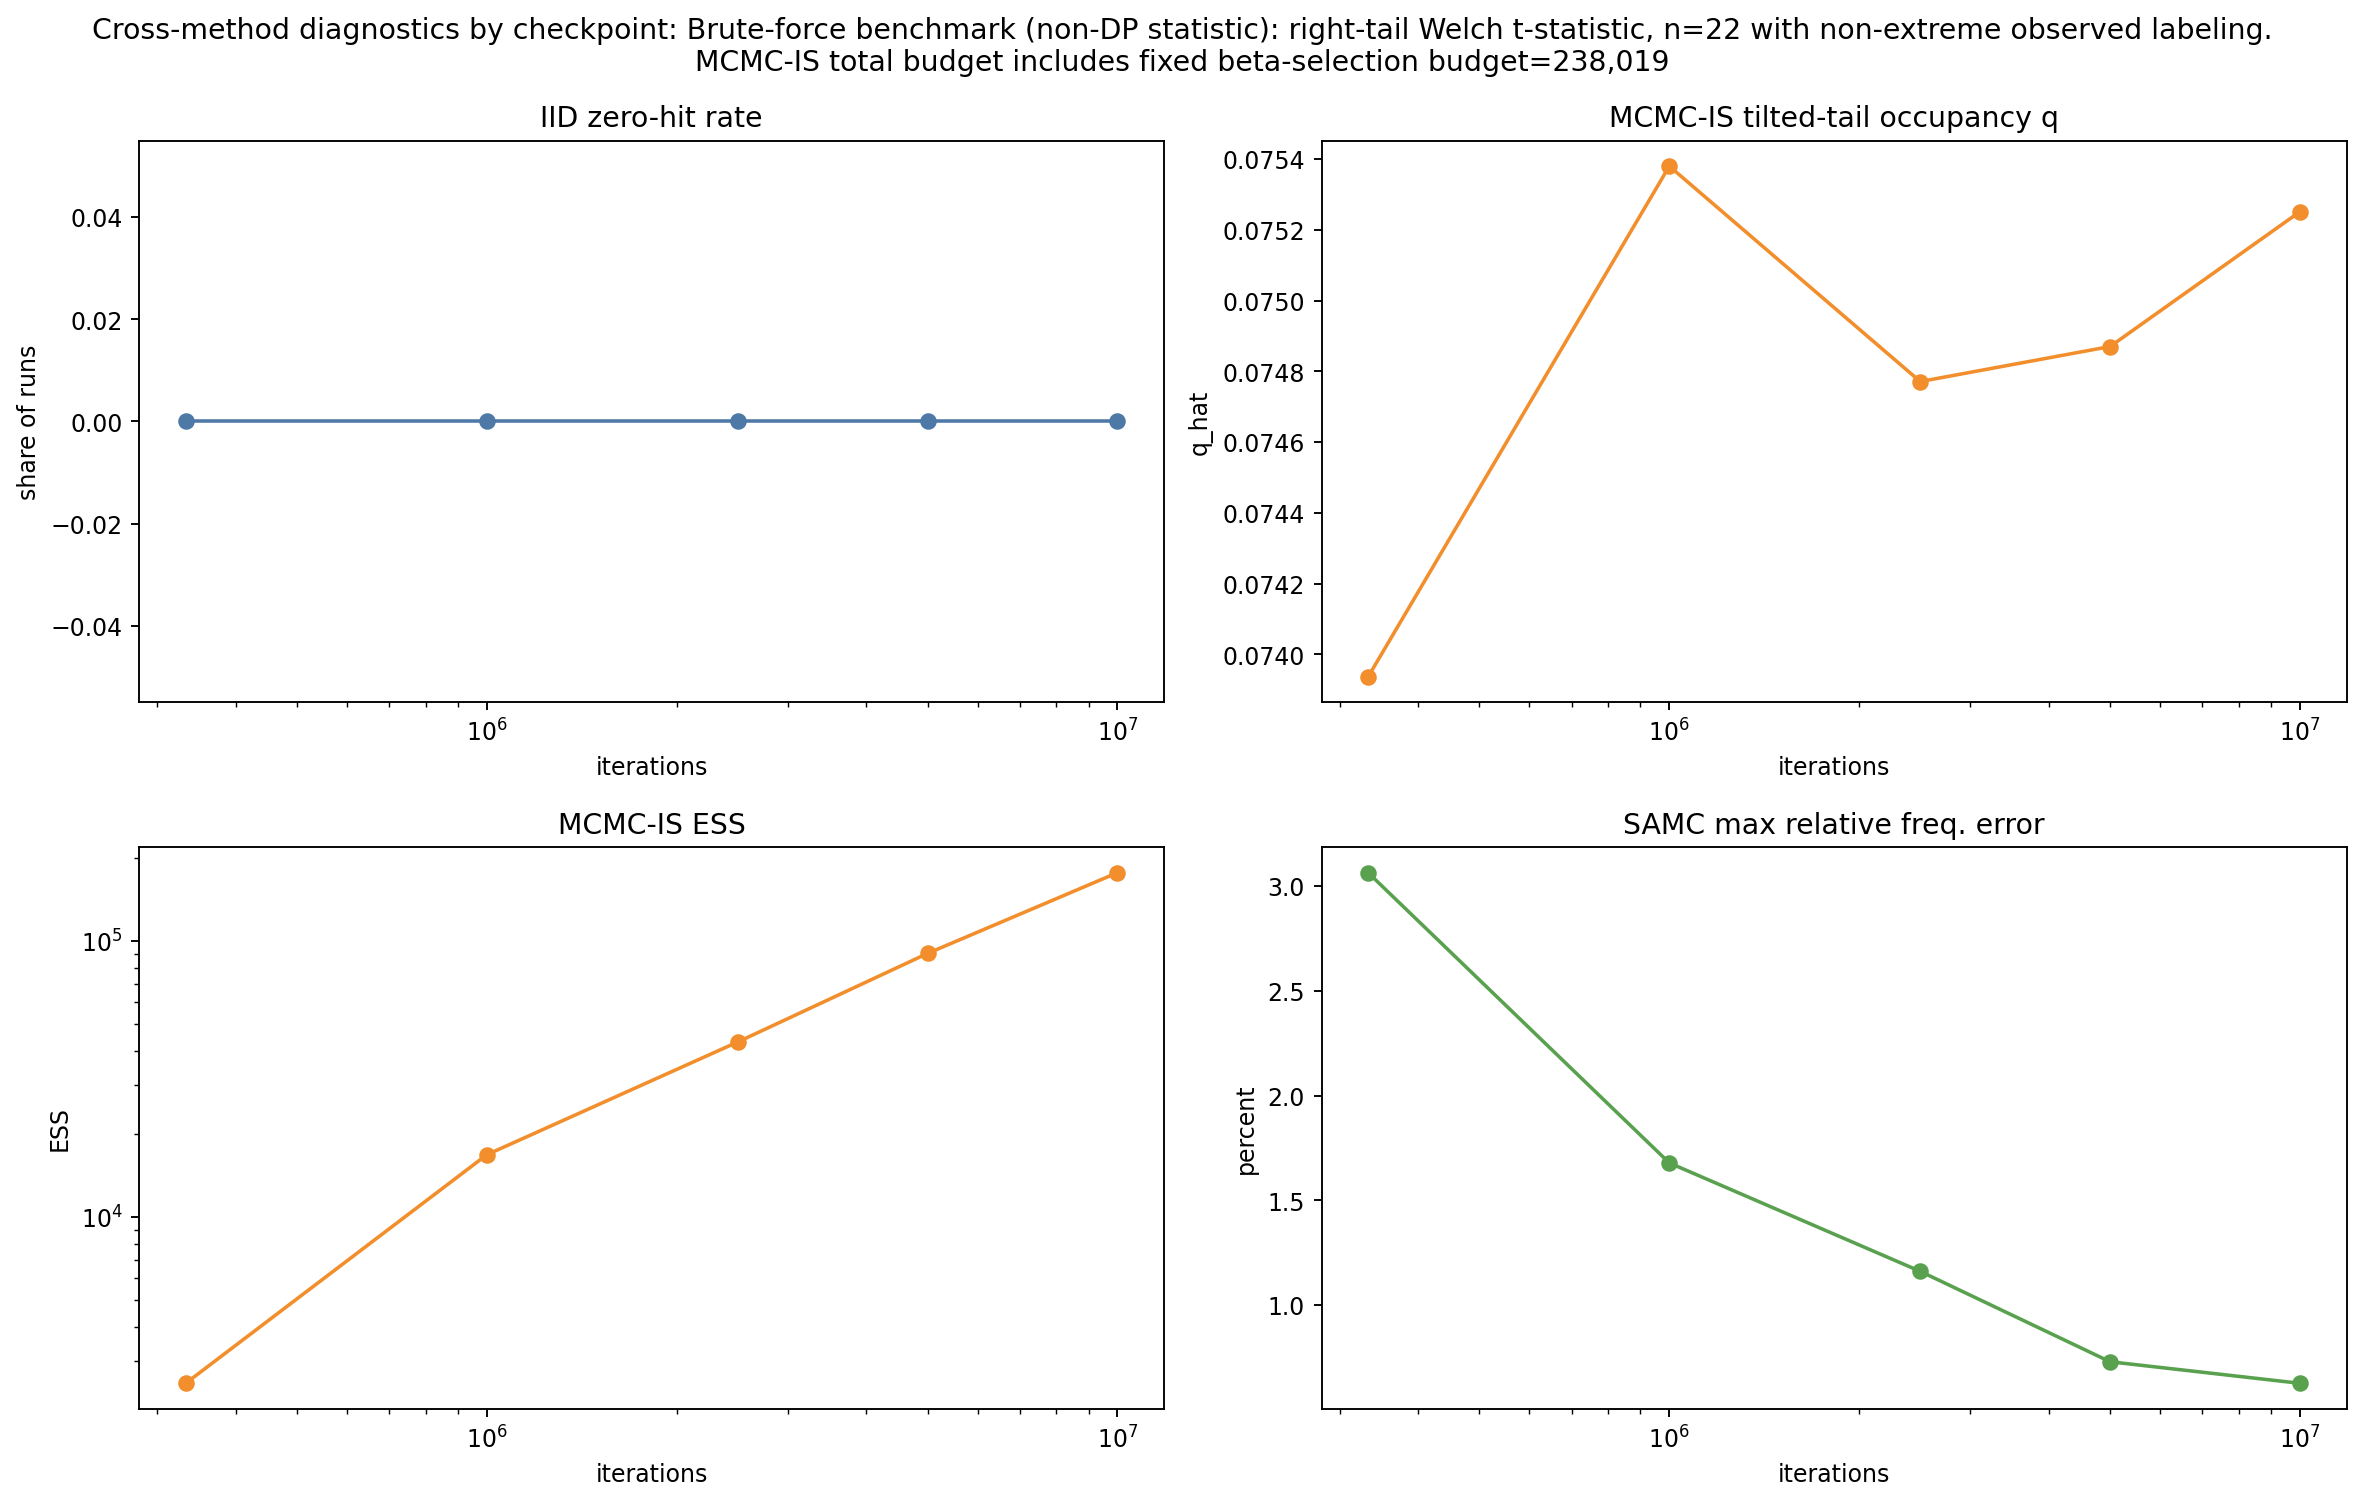

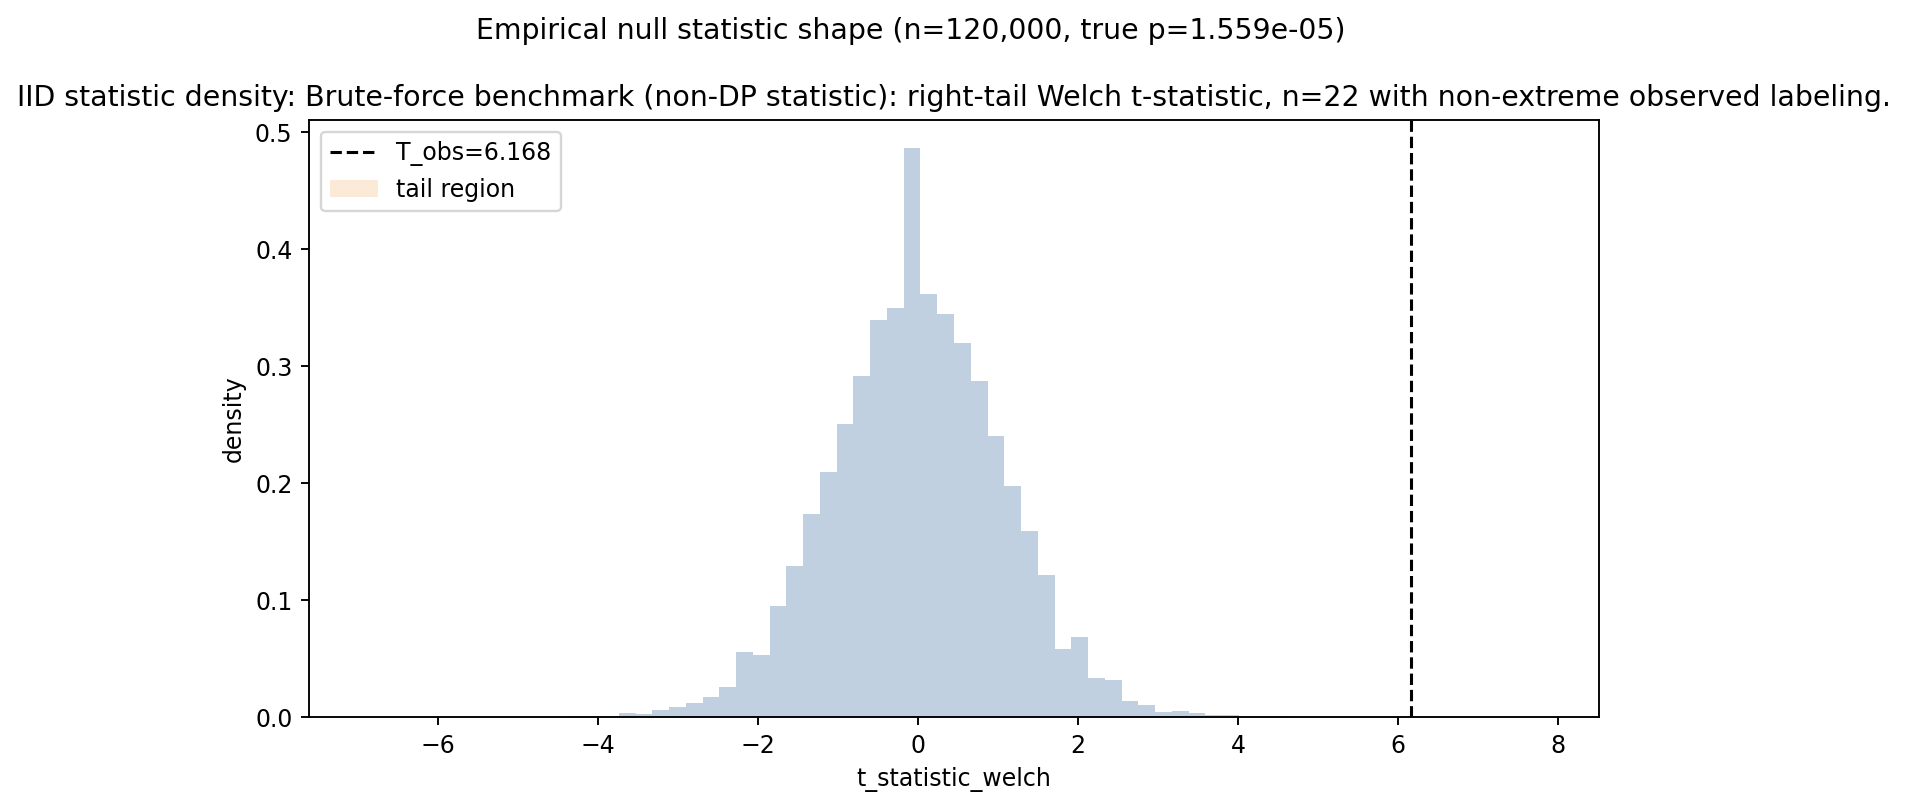

In [5]:
if SAVE_OUTPUTS and run_dir is not None:
    print(f"Saved outputs under: {run_dir}")
    for scenario in scenarios:
        scenario_dir = run_dir / scenario.key
        print(f"\n{scenario.key}")
        display(Image(filename=str(scenario_dir / "cross_method_max_budget.png")))
        display(Image(filename=str(scenario_dir / "cross_method_convergence.png")))
        display(Image(filename=str(scenario_dir / "cross_method_diagnostics.png")))
        display(Image(filename=str(scenario_dir / "iid_density.png")))
else:
    print("SAVE_OUTPUTS=False, so no saved figures to display.")

## Reload Saved Results Without Rerunning

In [6]:
# RELOAD_SCENARIO_DIR = None
# # Example:
# # RELOAD_SCENARIO_DIR = project_root / "results" / "cross_method_notebook" / "20260306_120000_cross_method" / "gwas_additive_score_n40"

# if RELOAD_SCENARIO_DIR is not None:
#     saved = load_cross_method_saved_output(RELOAD_SCENARIO_DIR)
#     print(json.dumps({
#         "scenario": saved["metadata"]["scenario"],
#         "exact_p": saved["metadata"]["exact_p"],
#         "mcmc_beta_selection_budget": saved["metadata"]["beta_workflow"]["beta_selection_eval_total"],
#     }, indent=2))
#     regen = regenerate_cross_method_plots_from_saved(RELOAD_SCENARIO_DIR)
#     for name, path in regen.items():
#         print(name, path)
#         display(Image(filename=str(path)))
# else:
#     print("Set RELOAD_SCENARIO_DIR to a saved scenario directory to regenerate plots from disk only.")
